# Exploration des variables pour un modele de feu en fonction du temps

Objectif du notebook:
- clarifier les variables disponibles,
- identifier la variable cible liee au feu,
- explorer la dimension temporelle,
- preparer une premiere selection de variables candidates pour comparer plusieurs modeles de feu.

Cible imposee pour cette version:
- frequence de feu regionale.

Le but n'est pas encore d'entrainer un modele final, mais de comprendre quoi garder, quoi transformer et quoi exclure avant la phase de modelisation.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = Path('.')
CSV_FILES = sorted(DATA_DIR.glob('*.csv'))
CSV_FILES

c:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.stats import gaussian_kde


[WindowsPath('AnnTemp.csv'),
 WindowsPath('BBBootCISap.csv'),
 WindowsPath('cor_binned_all2annual-corrected.csv'),
 WindowsPath('FFBootCISap.csv'),
 WindowsPath('FSBootCISap.csv'),
 WindowsPath('Human.csv'),
 WindowsPath('Lake_fire_frequency_24nov2023.csv'),
 WindowsPath('M15_depths.csv'),
 WindowsPath('M15_names.csv'),
 WindowsPath('M15_spec.csv'),
 WindowsPath('O15_depths.csv'),
 WindowsPath('O15_names.csv'),
 WindowsPath('O15_spec.csv'),
 WindowsPath('Pollen50Reg.csv'),
 WindowsPath('Regional_pollen_depths.csv'),
 WindowsPath('Regional_pollen_names.csv'),
 WindowsPath('Regional_pollen_spec.csv')]

## 1. Chargement des donnees et verification du schema

Cette section charge tous les fichiers CSV disponibles, affiche les premieres lignes et resume la structure generale de chaque table.

In [3]:
def read_csv_robust(path: Path) -> pd.DataFrame:
    """Read a CSV file with a few separator fallbacks."""
    for kwargs in (
        dict(sep=None, engine='python'),
        dict(sep=';'),
        dict(sep=','),
    ):
        try:
            return pd.read_csv(path, **kwargs)
        except Exception:
            continue
    return pd.read_csv(path, encoding='utf-8', errors='ignore')


def summarize_df(name: str, df: pd.DataFrame) -> None:
    print(f"\n=== {name} ===")
    print(f"shape: {df.shape}")
    display(df.head(3))
    display(pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
    }))


tables = {}
for csv_path in CSV_FILES:
    try:
        tables[csv_path.stem] = read_csv_robust(csv_path)
    except Exception as exc:
        print(f"[skip] {csv_path.name}: {exc}")

print(f"Fichiers CSV charges: {len(tables)}")
list(tables.keys())

Fichiers CSV charges: 17


['AnnTemp',
 'BBBootCISap',
 'cor_binned_all2annual-corrected',
 'FFBootCISap',
 'FSBootCISap',
 'Human',
 'Lake_fire_frequency_24nov2023',
 'M15_depths',
 'M15_names',
 'M15_spec',
 'O15_depths',
 'O15_names',
 'O15_spec',
 'Pollen50Reg',
 'Regional_pollen_depths',
 'Regional_pollen_names',
 'Regional_pollen_spec']

## 2. Nettoyage initial et gestion des valeurs manquantes

On identifie les doublons, les valeurs manquantes et les colonnes potentiellement incoherentes avant de construire les variables d'analyse.

## 3. Analyse de la variable cible liee au feu

On repere la ou les variables cibles candidates pour le feu, on examine leur distribution et on verifie si une version continue ou discrete est la plus pertinente.

In [4]:
from sklearn.linear_model import LinearRegression


def find_first_matching_column(df: pd.DataFrame, patterns):
    for pattern in patterns:
        matches = [col for col in df.columns if pattern.lower() in str(col).lower()]
        if matches:
            return matches[0]
    return None


def build_analysis_frame(tables):
    time_patterns = ['Age', 'age', 'Year', 'year', 'Time', 'time', 'Date', 'date', 'annee', 'Année']
    target_patterns = ['Mean', 'mean', 'freq', 'frequency', 'fire']

    if 'FFBootCISap' in tables:
        base_name = 'FFBootCISap'
    else:
        base_name = next(
            (
                name
                for name, df in tables.items()
                if find_first_matching_column(df, time_patterns) is not None
                and find_first_matching_column(df, target_patterns) is not None
            ),
            None,
        )

    if base_name is None:
        raise ValueError('No suitable time series table was found for the frequency analysis.')

    base_df = tables[base_name].copy().drop_duplicates().reset_index(drop=True)
    time_col = find_first_matching_column(base_df, time_patterns)
    target_col = find_first_matching_column(base_df, target_patterns)

    if time_col is None:
        raise ValueError(f'No time column found in {base_name}.')
    if target_col is None:
        raise ValueError(f'No target column found in {base_name}.')

    base_df[time_col] = pd.to_numeric(base_df[time_col], errors='coerce')
    base_df[target_col] = pd.to_numeric(base_df[target_col], errors='coerce')
    base_df = base_df.dropna(subset=[time_col, target_col]).sort_values(time_col).reset_index(drop=True)

    merged_frames = []
    for name, df in tables.items():
        df_work = df.copy().drop_duplicates().reset_index(drop=True)
        table_time_col = find_first_matching_column(df_work, time_patterns)
        if table_time_col is None:
            continue

        numeric_cols = df_work.select_dtypes(include=np.number).columns.tolist()
        if table_time_col in numeric_cols:
            numeric_cols.remove(table_time_col)

        if not numeric_cols:
            continue

        temp = df_work[[table_time_col] + numeric_cols].copy()
        temp[table_time_col] = pd.to_numeric(temp[table_time_col], errors='coerce')
        temp = temp.dropna(subset=[table_time_col]).drop_duplicates(subset=[table_time_col]).sort_values(table_time_col)

        if name == base_name:
            temp = temp.rename(columns={table_time_col: time_col})
        else:
            temp = temp.rename(columns={table_time_col: time_col, **{col: f'{name}__{col}' for col in numeric_cols}})

        merged_frames.append(temp)

    if not merged_frames:
        raise ValueError('Unable to build a merged analysis frame from the CSV files.')

    analysis_time = merged_frames[0]
    for temp in merged_frames[1:]:
        analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')

    analysis_time = analysis_time.sort_values(time_col).reset_index(drop=True)
    numeric_analysis_cols = [
        col for col in analysis_time.columns
        if col != time_col and pd.api.types.is_numeric_dtype(analysis_time[col])
    ]
    if numeric_analysis_cols:
        analysis_time[numeric_analysis_cols] = (
            analysis_time[numeric_analysis_cols]
            .interpolate(limit_direction='both')
            .ffill()
            .bfill()
        )

    analysis_df = base_df.copy()
    return analysis_df, analysis_time, time_col, target_col, base_name


def coerce_time_to_numeric(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors='coerce')
    if numeric.notna().any():
        return numeric.astype(float)

    parsed = pd.to_datetime(series, errors='coerce')
    if parsed.notna().any():
        return pd.Series(parsed.view('int64'), index=series.index, dtype='float64')

    return pd.Series(np.arange(len(series)), index=series.index, dtype='float64')


def run_linear_by_period(df, target_col, time_col_name, period_years, test_frac=0.2, min_samples=30):
    if time_col_name not in df.columns or target_col not in df.columns:
        raise ValueError(f'Missing required columns: {time_col_name} and/or {target_col}.')

    work = df[[time_col_name, target_col]].copy()
    work[target_col] = pd.to_numeric(work[target_col], errors='coerce')
    work['_time_numeric'] = coerce_time_to_numeric(work[time_col_name])
    work = work.dropna(subset=['_time_numeric', target_col]).sort_values('_time_numeric').reset_index(drop=True)

    if work.empty:
        return pd.DataFrame(), pd.DataFrame()

    period_offset = work['_time_numeric'].min()
    work['_period_id'] = np.floor((work['_time_numeric'] - period_offset) / float(period_years)).astype(int)

    metrics_rows = []
    preds_rows = []

    for period_id, period_df in work.groupby('_period_id', sort=True):
        period_df = period_df.sort_values('_time_numeric').reset_index(drop=True)
        if len(period_df) < min_samples:
            continue

        split_idx = int(round(len(period_df) * (1 - test_frac)))
        split_idx = max(1, min(split_idx, len(period_df) - 1))
        if split_idx <= 0 or split_idx >= len(period_df):
            continue

        train_df = period_df.iloc[:split_idx].copy()
        test_df = period_df.iloc[split_idx:].copy()
        if train_df.empty or test_df.empty:
            continue

        model = LinearRegression()
        model.fit(train_df[['_time_numeric']], train_df[target_col])
        predictions = model.predict(test_df[['_time_numeric']])

        metrics_rows.append({
            'period_years': period_years,
            'period_id': int(period_id),
            'n_train': len(train_df),
            'n_test': len(test_df),
            'MAE': mean_absolute_error(test_df[target_col], predictions),
            'RMSE': float(np.sqrt(mean_squared_error(test_df[target_col], predictions))),
            'R2': r2_score(test_df[target_col], predictions),
        })

        for time_value, truth_value, pred_value in zip(test_df[time_col_name], test_df[target_col], predictions):
            preds_rows.append({
                time_col_name: time_value,
                target_col: truth_value,
                'pred': pred_value,
                'period_years': period_years,
            })

    metrics_df = pd.DataFrame(metrics_rows)
    preds_df = pd.DataFrame(preds_rows)
    if not metrics_df.empty:
        metrics_df = metrics_df.sort_values(['period_years', 'period_id']).reset_index(drop=True)
    if not preds_df.empty:
        preds_df = preds_df.sort_values([time_col_name, 'period_years']).reset_index(drop=True)
    return metrics_df, preds_df


analysis_df, analysis_time, time_col, candidate_target, source_table_name = build_analysis_frame(tables)
print(f'Analysis table: {source_table_name}')
print(f'Time column: {time_col}')
print(f'Target column: {candidate_target}')
print(f'Analysis rows: {len(analysis_time)} | columns: {len(analysis_time.columns)}')

display(analysis_df.head(3))
display(analysis_time.head(3))


C:\Users\lenovo\AppData\Local\Temp\ipykernel_24588\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_24588\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_24588\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_24588\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge

Analysis table: FFBootCISap
Time column: Age
Target column: Mean
Analysis rows: 14263 | columns: 44


,Age,Mean,CI,Infe,Supe
0,-62,0.00397,0.9,0.002448,0.005514
1,-61,0.00397,0.9,0.002409,0.005545
2,-60,0.00397,0.9,0.002462,0.005588


,Age,AnnTemp__AnnTemp,AnnTemp__Unnamed: 2,AnnTemp__Unnamed: 3,AnnTemp__Unnamed: 4,BBBootCISap__Mean,BBBootCISap__CI,BBBootCISap__Infe,BBBootCISap__Supe,Mean,CI,Infe,Supe,FSBootCISap__Mean,FSBootCISap__CI,FSBootCISap__Infe,FSBootCISap__Supe,Human__human,M15_depths__depths,M15_depths__Depth,M15_depths__Age_OLD,O15_depths__depths,O15_depths__Depth,O15_depths__Age_OLD,Pollen50Reg__Abies,Pollen50Reg__Cupressaceae,Pollen50Reg__Larix,Pollen50Reg__Picea,Pollen50Reg__Pinus,Pollen50Reg__Alnus,Pollen50Reg__Betula,Pollen50Reg__Populus,Pollen50Reg__Quercus,Pollen50Reg__Salix,Pollen50Reg__Ulmus,Pollen50Reg__Ambrosia,Pollen50Reg__Artemisia,Pollen50Reg__Asteraceae,Pollen50Reg__Chenopodium,Pollen50Reg__Cyperaceae,Pollen50Reg__Poaceae,Pollen50Reg__Aquatics,Regional_pollen_depths__depths,Regional_pollen_depths__Depth
0,-62.0,-0.124983,NaN,NaN,NaN,0.023641,0.9,0.008164,0.038994,0.00397,0.9,0.002448,0.005514,0.688920,0.9,0.621528,0.754815,4.528384,570.000000,0.000000,-62.000000,390.000000,0.000000,-62.000000,1.418909,0.710853,1.248406,12.676318,56.014300,3.228284,11.661753,0.385694,1.374823,0.526785,0.294370,1.237380,1.713570,0.558144,0.990300,0.466820,1.461328,1.020428,1.000000,1.000000
1,-61.0,-0.124983,NaN,NaN,NaN,0.023339,0.9,0.009347,0.037836,0.00397,0.9,0.002409,0.005545,0.688738,0.9,0.620918,0.757118,4.528384,570.181818,0.181818,-60.963636,390.140845,0.140845,-60.957746,1.412361,0.714840,1.246453,12.636663,56.063914,3.230229,11.671256,0.386071,1.372305,0.525461,0.292816,1.241068,1.716516,0.557224,0.986683,0.468898,1.467987,1.017756,1.009615,1.961538
2,-60.0,-0.124983,NaN,NaN,NaN,0.023037,0.9,0.010253,0.036165,0.00397,0.9,0.002462,0.005588,0.688555,0.9,0.618522,0.761105,4.528384,570.363636,0.363636,-59.927273,390.281690,0.281690,-59.915493,1.405813,0.718826,1.244500,12.597008,56.113528,3.232174,11.680759,0.386449,1.369787,0.524138,0.291262,1.244755,1.719462,0.556304,0.983067,0.470976,1.474647,1.015085,1.019231,2.923077


## Synthese et prochaines etapes

A la fin de cette exploration, les points a retenir sont:
- la variable cible la plus pertinente,
- les colonnes de temps exploitables,
- les variables explicatives stables et informatives,
- les variables a exclure car trop redondantes, trop incompletes ou non causales.

La suite logique est de garder un petit ensemble de variables candidates, de tester plusieurs modeles de base, puis de passer a une validation temporelle plus rigoureuse.

## 12. Regression lineaire par periodes modulables pour l'intensite

Ici, on applique la meme logique a l'intensite du feu, avec un parametre de periode modulable.
Selon la nomenclature du projet, la table la plus proche de cette idee est souvent celle de la taille/severite (FS) ou de la biomasse brulee (BB).
L'objectif est de tester si une tendance temporelle lineaire existe aussi pour ce proxy.

Objectif cible: intensite du feu
Table d'analyse choisie: FSBootCISap


,Age,Mean,CI,Infe,Supe
0,-62,0.688920,0.9,0.621528,0.754815
1,-61,0.688738,0.9,0.620918,0.757118
2,-60,0.688555,0.9,0.618522,0.761105
3,-59,0.688328,0.9,0.620096,0.758085
4,-58,0.688100,0.9,0.617424,0.755407


,missing_count


Cible fixee (intensite): Mean


count    13063.000000
mean         0.668183
std          0.057625
min          0.569100
25%          0.627392
50%          0.651283
75%          0.694309
max          0.827715
Name: Mean, dtype: float64

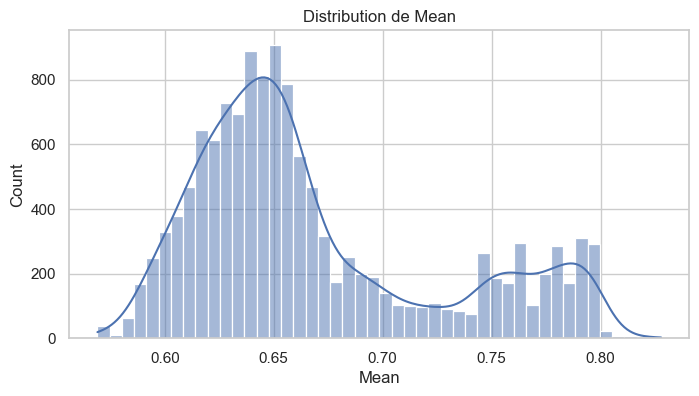

Colonne de temps candidate pour l'intensite: Age


,period_years,period_id,n_train,n_test,MAE,RMSE,R2
0,100,0,80,20,0.000643,0.000781,-0.662820
1,100,1,80,20,0.014623,0.014678,-51.728816
2,100,2,80,20,0.003581,0.003625,-35.688329
3,100,3,80,20,0.007932,0.007954,-29.990608
4,100,4,80,20,0.008184,0.008245,-250.304554
5,100,5,80,20,0.009259,0.009322,-77.678894
6,100,6,80,20,0.003857,0.003914,-590.099502
7,100,7,80,20,0.008896,0.009113,-14.261745
8,100,8,80,20,0.003318,0.003847,0.134389
9,100,9,80,20,0.009563,0.010859,-5.256082


Performance moyenne par taille de periode pour l'intensite:


,period_years,MAE,RMSE,R2
0,100,0.016144,0.016877,-150.080712
1,200,0.016513,0.018081,-22.325192
3,500,0.015909,0.018105,-13.932213
2,300,0.018636,0.020877,-11.359780
4,1000,0.019702,0.022043,-20.119289
5,1500,0.022229,0.026158,-3.617105
6,2000,0.030252,0.035662,-2.654896


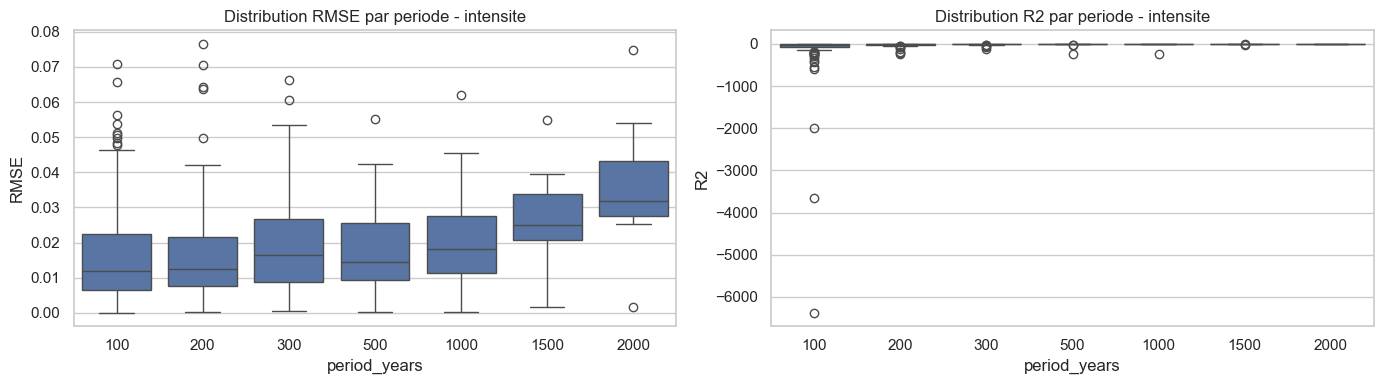

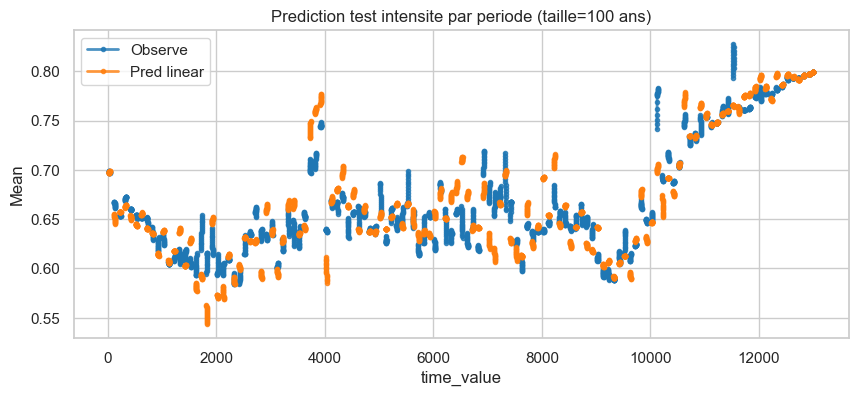

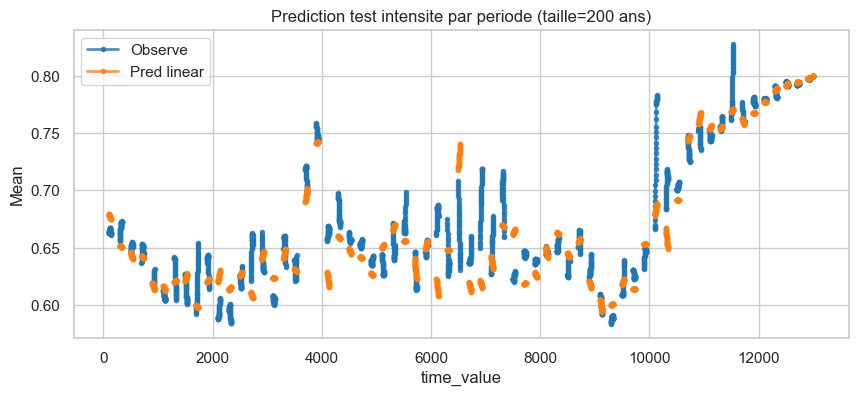

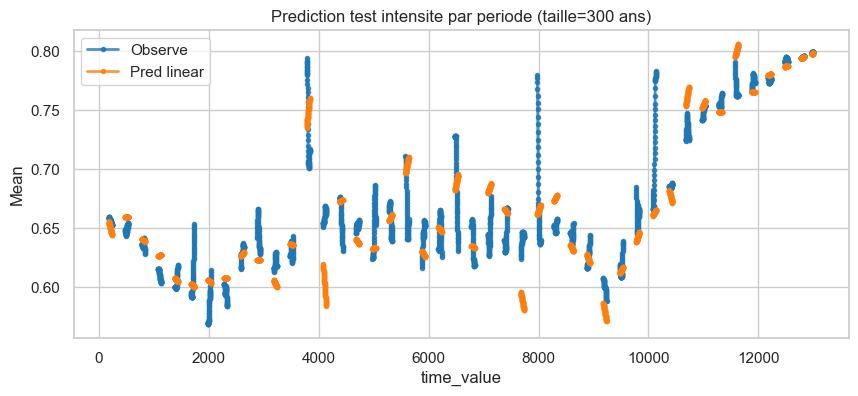

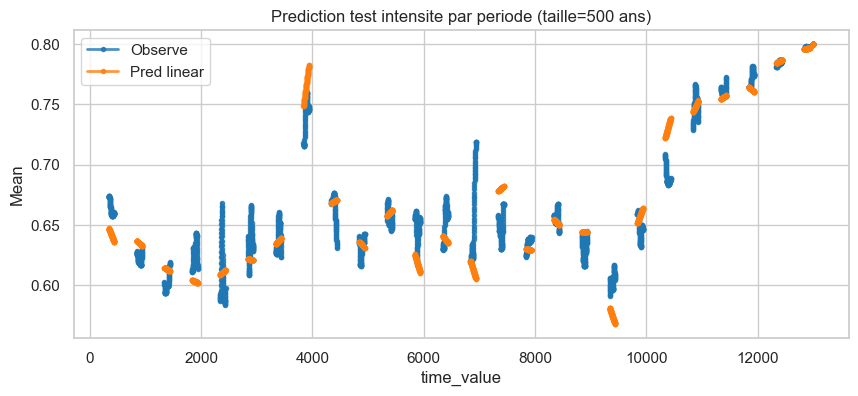

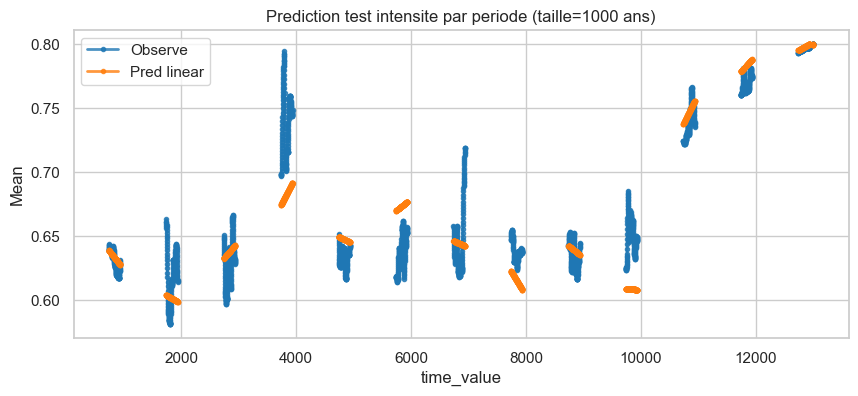

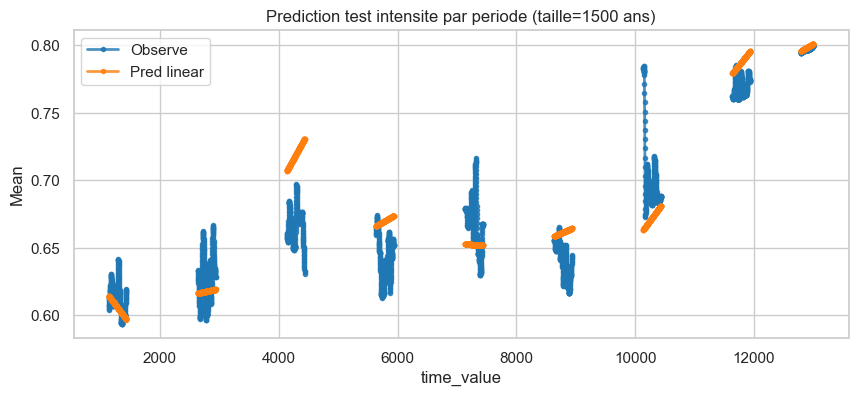

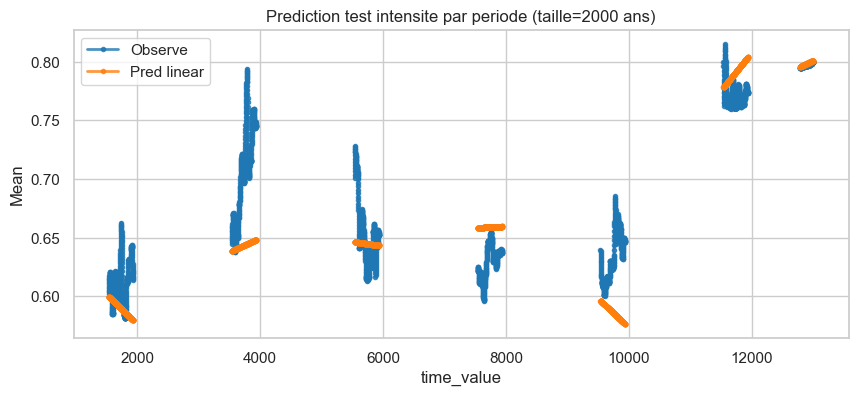

In [5]:
INTENSITY_OBJECTIVE = "intensite du feu"
INTENSITY_TABLE_PRIORITY = [
    'FSBootCISap',
    'BBBootCISap',
]
INTENSITY_COLUMN_PATTERNS = [
    'regfs',
    'regional_fire_size',
    'fire_size',
    'severity',
    'intensity',
    'bb',
    'biomass',
]
INTENSITY_BY_TABLE = {
    'FSBootCISap': 'Mean',
    'BBBootCISap': 'Mean',
}

# Choix explicite de la table la plus proche de l'intensite
intensity_name = next((name for name in INTENSITY_TABLE_PRIORITY if name in tables), None)
if intensity_name is None:
    intensity_name = next(
        (
            name for name, df in tables.items()
            if find_first_matching_column(df, INTENSITY_COLUMN_PATTERNS) is not None
        ),
        next(iter(tables)),
    )

intensity_df = tables[intensity_name].copy()
print(f"Objectif cible: {INTENSITY_OBJECTIVE}")
print(f"Table d'analyse choisie: {intensity_name}")
display(intensity_df.head())

intensity_df = intensity_df.drop_duplicates().reset_index(drop=True)
intensity_missing = intensity_df.isna().sum().sort_values(ascending=False)
display(intensity_missing[intensity_missing > 0].to_frame('missing_count'))

intensity_target = None
if intensity_name in INTENSITY_BY_TABLE and INTENSITY_BY_TABLE[intensity_name] in intensity_df.columns:
    intensity_target = INTENSITY_BY_TABLE[intensity_name]
else:
    intensity_target = find_first_matching_column(intensity_df, INTENSITY_COLUMN_PATTERNS)

if intensity_target is None:
    rescue = None
    for name, df in tables.items():
        mapped_col = INTENSITY_BY_TABLE.get(name)
        if mapped_col in df.columns:
            rescue = (name, mapped_col)
            break
        col = find_first_matching_column(df, INTENSITY_COLUMN_PATTERNS)
        if col is not None:
            rescue = (name, col)
            break

    if rescue is None:
        raise ValueError(
            "Aucune colonne compatible avec l'intensite n'a ete detectee automatiquement. "
            "Definis manuellement INTENSITY_BY_TABLE ou INTENSITY_COLUMN_PATTERNS."
        )

    intensity_name, intensity_target = rescue
    intensity_df = tables[intensity_name].drop_duplicates().reset_index(drop=True)
    print(f"Table recalee automatiquement vers: {intensity_name}")

print(f"Cible fixee (intensite): {intensity_target}")

if intensity_target is not None:
    intensity_series = intensity_df[intensity_target]
    if pd.api.types.is_numeric_dtype(intensity_series):
        display(intensity_series.describe())
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.histplot(intensity_series.dropna(), kde=True, ax=ax)
        ax.set_title(f"Distribution de {intensity_target}")
        plt.show()
    else:
        display(intensity_series.value_counts(dropna=False).to_frame('count'))

intensity_time_col = find_first_matching_column(intensity_df, ['year', 'age', 'time', 'date', 'annee'])
print(f"Colonne de temps candidate pour l'intensite: {intensity_time_col}")

intensity_time = intensity_df.copy()
if intensity_time_col is not None:
    if np.issubdtype(intensity_time[intensity_time_col].dtype, np.number):
        intensity_time['time_value'] = pd.to_numeric(intensity_time[intensity_time_col], errors='coerce')
    else:
        parsed_time = pd.to_datetime(intensity_time[intensity_time_col], errors='coerce')
        intensity_time['time_value'] = parsed_time

if intensity_target is not None and intensity_time_col is not None and pd.api.types.is_numeric_dtype(intensity_time[intensity_target]):
    period_options_intensity = [100, 200, 300, 500, 1000, 1500, 2000]
    intensity_metrics_all = []
    intensity_preds_all = []
    plot_time_col_intensity = 'time_value' if 'time_value' in intensity_time.columns else intensity_time_col

    for p in period_options_intensity:
        metrics_p, preds_p = run_linear_by_period(
            intensity_time,
            target_col=intensity_target,
            time_col_name=plot_time_col_intensity,
            period_years=p,
            test_frac=0.2,
            min_samples=30,
        )
        if not metrics_p.empty:
            intensity_metrics_all.append(metrics_p)
        if not preds_p.empty:
            intensity_preds_all.append(preds_p)

    intensity_metrics_by_period = pd.concat(intensity_metrics_all, ignore_index=True) if intensity_metrics_all else pd.DataFrame()
    intensity_preds_by_period = pd.concat(intensity_preds_all, ignore_index=True) if intensity_preds_all else pd.DataFrame()

    if not intensity_metrics_by_period.empty:
        display(intensity_metrics_by_period.head(20))

        intensity_summary = (
            intensity_metrics_by_period.groupby('period_years')[['MAE', 'RMSE', 'R2']]
            .mean()
            .reset_index()
            .sort_values('RMSE')
        )
        print('Performance moyenne par taille de periode pour l\'intensite:')
        display(intensity_summary)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sns.boxplot(data=intensity_metrics_by_period, x='period_years', y='RMSE', ax=axes[0])
        axes[0].set_title('Distribution RMSE par periode - intensite')

        sns.boxplot(data=intensity_metrics_by_period, x='period_years', y='R2', ax=axes[1])
        axes[1].set_title('Distribution R2 par periode - intensite')
        plt.tight_layout()
        plt.show()

        if not intensity_preds_by_period.empty:
            def plot_broken_lines(ax, x, y, label=None, color=None, alpha=0.8, marker='-', linewidth=2, **kwargs):
                x_ser = pd.Series(x).reset_index(drop=True)
                y_ser = pd.Series(y).reset_index(drop=True)
                if len(x_ser) == 0:
                    return
                try:
                    if np.issubdtype(x_ser.dtype, np.datetime64):
                        x_num = x_ser.view('int64').astype(float)
                    else:
                        x_num = pd.to_numeric(x_ser, errors='coerce').values.astype(float)
                except Exception:
                    x_num = pd.to_numeric(x_ser, errors='coerce').values.astype(float)

                if len(x_num) <= 1 or np.all(np.isnan(x_num)):
                    ax.plot(x_ser, y_ser, label=label, color=color, alpha=alpha, marker=marker, linewidth=linewidth, **kwargs)
                    return

                diffs = np.diff(x_num)
                pos = diffs[~np.isnan(diffs) & (diffs > 0)]
                thresh = (np.median(pos) * 3) if len(pos) > 0 else 0

                segments = []
                start = 0
                for i, d in enumerate(diffs):
                    if thresh > 0 and d > thresh:
                        segments.append((start, i + 1))
                        start = i + 1
                segments.append((start, len(x_ser)))

                first = True
                for s, e in segments:
                    if s >= e:
                        continue
                    if first and label is not None:
                        ax.plot(x_ser.iloc[s:e], y_ser.iloc[s:e], label=label, color=color, alpha=alpha, marker=marker, linewidth=linewidth, **kwargs)
                        first = False
                    else:
                        ax.plot(x_ser.iloc[s:e], y_ser.iloc[s:e], color=color, alpha=alpha, marker=marker, linewidth=linewidth, **kwargs)

            for p in sorted(intensity_preds_by_period['period_years'].unique()):
                sub = intensity_preds_by_period[intensity_preds_by_period['period_years'] == p].sort_values(plot_time_col_intensity)
                fig, ax = plt.subplots(figsize=(10, 4))
                plot_broken_lines(ax, sub[plot_time_col_intensity], sub[intensity_target], label='Observe', color='tab:blue', alpha=0.8, marker='.', linewidth=2)
                plot_broken_lines(ax, sub[plot_time_col_intensity], sub['pred'], label='Pred linear', color='tab:orange', alpha=0.8, marker='.', linewidth=2)
                ax.set_title(f'Prediction test intensite par periode (taille={p} ans)')
                ax.set_xlabel(plot_time_col_intensity)
                ax.set_ylabel(intensity_target)
                ax.legend()
                plt.show()
    else:
        print('Aucune periode valide pour la regression lineaire de l\'intensite avec les parametres actuels.')
else:
    print('Impossible de lancer la regression lineaire de l\'intensite: cible ou temps non definis.')

## 13. Version avec split aleatoire pour la frequence et l'intensite

Cette version sert de point de comparaison avec la version chronologique.
Le split est aleatoire, avec une proportion de test fixe et une graine pour la reproductibilite.
On conserve la meme logique de preparation des variables et on retire les colonnes de fuite.

In [6]:
from sklearn.model_selection import train_test_split


def prepare_random_split_frame(df, target_col, time_col_name=None):
    work = df.dropna(subset=[target_col]).copy()

    leakage_patterns = ['ci', 'infe', 'supe', 'lower', 'upper', 'bound', 'interval']
    excluded_cols = {target_col}
    if time_col_name is not None:
        excluded_cols.add(time_col_name)

    excluded_cols.update(
        col for col in work.columns
        if any(pat in str(col).lower() for pat in leakage_patterns)
    )

    feature_cols = [col for col in work.columns if col not in excluded_cols]
    X = work[feature_cols]
    y = work[target_col]

    return work, X, y, excluded_cols



def run_random_split_benchmark(df, target_col, time_col_name=None, test_size=0.2, random_state=42):
    work, X, y, excluded_cols = prepare_random_split_frame(df, target_col, time_col_name=time_col_name)

    print('Colonnes exclues (fuite/structure):', sorted(excluded_cols))

    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
    print('Features numeriques retenues:', numeric_features)
    print('Features categoricielles retenues:', categorical_features)

    if len(work) < 20 or not (numeric_features or categorical_features):
        print('Pas assez de donnees ou de variables pour un benchmark aleatoire de base.')
        return pd.DataFrame()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
    )

    try:
        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', encoder)]), categorical_features),
        ],
        remainder='drop',
    )

    models = {
        'DummyMean': DummyRegressor(strategy='mean'),
        'Ridge': Ridge(alpha=1.0),
        'RandomForest': RandomForestRegressor(n_estimators=200, random_state=random_state),
        'HistGradientBoosting': HistGradientBoostingRegressor(random_state=random_state),
    }

    results = []
    for model_name, model in models.items():
        pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
        pipe.fit(X_train, y_train)
        predictions = pipe.predict(X_test)
        mse = mean_squared_error(y_test, predictions)
        results.append({
            'model': model_name,
            'MAE': mean_absolute_error(y_test, predictions),
            'RMSE': float(np.sqrt(mse)),
            'R2': r2_score(y_test, predictions),
        })

    return pd.DataFrame(results).sort_values('RMSE')


if candidate_target is not None and pd.api.types.is_numeric_dtype(analysis_time[candidate_target]):
    random_freq_results = run_random_split_benchmark(
        analysis_time,
        target_col=candidate_target,
        time_col_name=time_col,
        test_size=0.2,
        random_state=42,
    )

    if not random_freq_results.empty:
        print('Benchmark aleatoire - frequence de feu regionale')
        display(random_freq_results)
else:
    print('Benchmark aleatoire frequence impossible: cible non definie ou non numerique.')


if intensity_target is not None and pd.api.types.is_numeric_dtype(intensity_time[intensity_target]):
    random_intensity_results = run_random_split_benchmark(
        intensity_time,
        target_col=intensity_target,
        time_col_name=intensity_time_col,
        test_size=0.2,
        random_state=42,
    )

    if not random_intensity_results.empty:
        print('Benchmark aleatoire - intensite du feu')
        display(random_intensity_results)
else:
    print('Benchmark aleatoire intensite impossible: cible non definie ou non numerique.')

Colonnes exclues (fuite/structure): ['Age', 'BBBootCISap__CI', 'BBBootCISap__Infe', 'BBBootCISap__Mean', 'BBBootCISap__Supe', 'CI', 'FSBootCISap__CI', 'FSBootCISap__Infe', 'FSBootCISap__Mean', 'FSBootCISap__Supe', 'Infe', 'Mean', 'Supe']
Features numeriques retenues: ['AnnTemp__AnnTemp', 'AnnTemp__Unnamed: 2', 'AnnTemp__Unnamed: 3', 'AnnTemp__Unnamed: 4', 'Human__human', 'M15_depths__depths', 'M15_depths__Depth', 'M15_depths__Age_OLD', 'O15_depths__depths', 'O15_depths__Depth', 'O15_depths__Age_OLD', 'Pollen50Reg__Abies', 'Pollen50Reg__Cupressaceae', 'Pollen50Reg__Larix', 'Pollen50Reg__Picea', 'Pollen50Reg__Pinus', 'Pollen50Reg__Alnus', 'Pollen50Reg__Betula', 'Pollen50Reg__Populus', 'Pollen50Reg__Quercus', 'Pollen50Reg__Salix', 'Pollen50Reg__Ulmus', 'Pollen50Reg__Ambrosia', 'Pollen50Reg__Artemisia', 'Pollen50Reg__Asteraceae', 'Pollen50Reg__Chenopodium', 'Pollen50Reg__Cyperaceae', 'Pollen50Reg__Poaceae', 'Pollen50Reg__Aquatics', 'Regional_pollen_depths__depths', 'Regional_pollen_depths_

c:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['AnnTemp__Unnamed: 2' 'AnnTemp__Unnamed: 3' 'AnnTemp__Unnamed: 4']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['AnnTemp__Unnamed: 2' 'AnnTemp__Unnamed: 3' 'AnnTemp__Unnamed: 4']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['AnnTemp__Unnamed: 2' 'AnnTemp__Unnamed: 3' 'AnnTemp__Unnamed: 4']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\sklearn\imp

Benchmark aleatoire - frequence de feu regionale


c:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['AnnTemp__Unnamed: 2' 'AnnTemp__Unnamed: 3' 'AnnTemp__Unnamed: 4']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,model,MAE,RMSE,R2
2,RandomForest,0.000003,0.000014,0.999893
3,HistGradientBoosting,0.000123,0.000152,0.987506
1,Ridge,0.000161,0.000203,0.977637
0,DummyMean,0.001110,0.001356,-0.001198


Colonnes exclues (fuite/structure): ['Age', 'CI', 'Infe', 'Mean', 'Supe']
Features numeriques retenues: ['time_value']
Features categoricielles retenues: []
Benchmark aleatoire - intensite du feu


,model,MAE,RMSE,R2
2,RandomForest,0.000446,0.000748,9.998352e-01
3,HistGradientBoosting,0.007744,0.011792,9.590177e-01
1,Ridge,0.036026,0.044843,4.073760e-01
0,DummyMean,0.046828,0.058251,-1.009653e-07


## 14. Modèles séquentiels pour la fréquence

Cette section compare des modèles de séries temporelles (LSTM, Transformer, PatchTST) sur la fréquence de feu avec un split chronologique. 
On teste chaque modèle avec les mêmes données, les mêmes métriques d'erreur et des visuels de comparaison.

**Modèles testés:**
- **LSTM**: Réseau de neurones récurrents (baseline)
- **Transformer**: Encoder Transformer simple avec encodage positionnel
- **PatchTST**: Basé sur le papier ICLR 2023, approche par patchs avec Transformer

In [7]:
import math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Périphérique utilisé: {device}')

# Configuration pour les modèles séquentiels
SEQ_INPUT_LEN = 24      # Nombre de pas de temps en entrée
SEQ_HORIZON = 6         # Nombre de pas à prédire
VAL_FRACTION = 0.2      # Proportion de validation
BATCH_SIZE = 32
EPOCHS = 12
LEARNING_RATE = 1e-3

# Préparer les données pour la fréquence
freq_source_df = analysis_time.copy() if 'analysis_time' in globals() else None
if freq_source_df is None:
    raise RuntimeError('analysis_time non trouvé. Exécute les cellules précédentes.')

freq_target_col = candidate_target if 'candidate_target' in globals() and candidate_target is not None else None
if freq_target_col is None or freq_target_col not in freq_source_df.columns:
    raise RuntimeError('La cible de fréquence n\'a pas été identifiée.')

# Identifier la colonne de temps
if 'time_value' in freq_source_df.columns:
    freq_time_col = 'time_value'
elif 'time_col' in globals() and time_col in freq_source_df.columns:
    freq_time_col = time_col
else:
    freq_time_col = '__row_order__'
    freq_source_df = freq_source_df.reset_index(drop=True).rename(columns={'index': freq_time_col})

# Nettoyer et trier
freq_source_df = freq_source_df.drop_duplicates().copy()
freq_source_df = freq_source_df.sort_values(freq_time_col).reset_index(drop=True)

# ===== CHANGEMENT PRINCIPAL: Charger UNIQUEMENT temps et mean (univarié) =====
# Sélectionner UNIQUEMENT la colonne temps et la cible (mean)
freq_work = freq_source_df[[freq_time_col, freq_target_col]].copy()
freq_work[freq_target_col] = pd.to_numeric(freq_work[freq_target_col], errors='coerce')

# Imputer les valeurs manquantes
freq_work[freq_target_col] = (
    freq_work[freq_target_col]
    .interpolate(limit_direction='both')
    .ffill()
    .bfill()
)

print(f'Mode univarié: Temps + Mean uniquement')
print(f'Variable cible: {freq_target_col}')
print(f'Colonne de temps: {freq_time_col}')
print(f'Lignes totales: {len(freq_work)}')
print(f'Data shape: {freq_work.shape}')
display(freq_work.head())

Périphérique utilisé: cpu
Mode univarié: Temps + Mean uniquement
Variable cible: Mean
Colonne de temps: Age
Lignes totales: 14263
Data shape: (14263, 2)


,Age,Mean
0,-62.0,0.003970
1,-61.0,0.003970
2,-60.0,0.003970
3,-59.0,0.003970
4,-58.0,0.003971


In [8]:
# Diviser train/validation avec split chronologique
split_row = int(len(freq_work) * (1 - VAL_FRACTION))
train_frame = freq_work.iloc[:split_row].copy()
val_start = max(0, split_row - SEQ_INPUT_LEN - SEQ_HORIZON + 1)
val_frame = freq_work.iloc[val_start:].copy()

# Normaliser les données (univarié)
target_scaler = StandardScaler()
freq_target_scaler = target_scaler

# Extraire les valeurs numériques
train_y = target_scaler.fit_transform(train_frame[[freq_target_col]])
val_y = target_scaler.transform(val_frame[[freq_target_col]])

print(f'Train: {len(train_y)} échantillons | Validation: {len(val_y)} échantillons')


class UnivariateSequenceDataset(Dataset):
    """Dataset pour fenêtres temporelles univariées."""
    def __init__(self, y_array, input_len=SEQ_INPUT_LEN, horizon=SEQ_HORIZON):
        self.y_array = y_array.astype(np.float32).flatten()
        self.input_len = input_len
        self.horizon = horizon

    def __len__(self):
        return max(0, len(self.y_array) - self.input_len - self.horizon + 1)

    def __getitem__(self, idx):
        x = self.y_array[idx : idx + self.input_len]
        y = self.y_array[idx + self.input_len : idx + self.input_len + self.horizon]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


train_ds = UnivariateSequenceDataset(train_y)
val_ds = UnivariateSequenceDataset(val_y)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Fenêtres train: {len(train_ds)} | Fenêtres val: {len(val_ds)}')
print(f'Taille d\'entrée: {SEQ_INPUT_LEN} | Horizon: {SEQ_HORIZON}')

Train: 11410 échantillons | Validation: 2882 échantillons
Fenêtres train: 11381 | Fenêtres val: 2853
Taille d'entrée: 24 | Horizon: 6


In [9]:
class PositionalEncoding(nn.Module):
    """Encodage positionnel pour Transformer."""
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class LSTMPatch(nn.Module):
    """LSTM avec patchs pour séries univariées."""
    def __init__(self, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, patch_size=4, 
                 hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.patch_size = patch_size
        self.num_patches = seq_len // patch_size
        
        # Projection du patch vers embedding
        self.patch_embedding = nn.Linear(patch_size, hidden_dim)
        
        # LSTM multi-couches
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Couches de décodage
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, pred_len)
        )
        
    def forward(self, x):
        # x: (batch, seq_len)
        batch_size = x.shape[0]
        
        # Reshape en patchs: (batch, num_patches, patch_size)
        x = x.view(batch_size, self.num_patches, self.patch_size)
        
        # Embedding des patchs
        x = self.patch_embedding(x)  # (batch, num_patches, hidden_dim)
        
        # LSTM
        lstm_out, (h_n, c_n) = self.lstm(x)  # (batch, num_patches, hidden_dim)
        
        # Prendre le dernier état
        x = lstm_out[:, -1, :]  # (batch, hidden_dim)
        
        # Prédiction
        out = self.fc(x)  # (batch, pred_len)
        return out


class TransformerPatch(nn.Module):
    """Transformer avec patchs pour séries univariées."""
    def __init__(self, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, patch_size=4,
                 d_model=128, nhead=8, num_layers=3, dropout=0.1, dim_ff=512):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.patch_size = patch_size
        self.num_patches = seq_len // patch_size
        
        # Projection du patch vers embedding
        self.patch_embedding = nn.Linear(patch_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            batch_first=True, dropout=dropout, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Décodeur
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, pred_len)
        )
        
    def forward(self, x):
        # x: (batch, seq_len)
        batch_size = x.shape[0]
        
        # Reshape en patchs
        x = x.view(batch_size, self.num_patches, self.patch_size)
        
        # Embedding et positional encoding
        x = self.patch_embedding(x)  # (batch, num_patches, d_model)
        x = self.pos_encoding(x)
        
        # Transformer
        x = self.transformer_encoder(x)  # (batch, num_patches, d_model)
        
        # Agrégation: moyenne + dernier token
        x = x.mean(dim=1) + x[:, -1, :]  # (batch, d_model)
        
        # Prédiction
        out = self.fc(x)
        return out


class NBeats(nn.Module):
    """N-BEATS: Neural Basis Expansion Analysis (état-de-l'art)."""
    def __init__(self, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, 
                 stack_types=['trend', 'seasonality'], num_blocks=3, 
                 hidden_dim=128, num_layers=4):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.stack_types = stack_types
        
        self.stacks = nn.ModuleList()
        for stack_type in stack_types:
            blocks = nn.ModuleList()
            for _ in range(num_blocks):
                blocks.append(self._create_block(hidden_dim, num_layers, stack_type))
            self.stacks.append(blocks)
    
    def _create_block(self, hidden_dim, num_layers, stack_type):
        """Crée un bloc N-BEATS."""
        net = nn.Sequential(
            nn.Linear(self.seq_len, hidden_dim),
            nn.ReLU()
        )
        for _ in range(num_layers - 1):
            net.add_module(f'fc', nn.Linear(hidden_dim, hidden_dim))
            net.add_module(f'relu', nn.ReLU())
        
        # Forecast head
        net.add_module('forecast_head', nn.Linear(hidden_dim, self.pred_len))
        return net
    
    def forward(self, x):
        # x: (batch, seq_len)
        forecast = torch.zeros(x.shape[0], self.pred_len, device=x.device)
        
        for stack in self.stacks:
            for block in stack:
                forecast = forecast + block(x)
        
        return forecast


class TemporalFusionTransformer(nn.Module):
    """Temporal Fusion Transformer simplifié pour univarié."""
    def __init__(self, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, 
                 d_model=128, nhead=8, num_layers=3, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        
        # Input processing
        self.input_embed = nn.Linear(1, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        
        # Static context variable (optionnel, pour cohérence)
        self.static_context = nn.Linear(1, d_model)
        
        # Temporal fusion attention
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            batch_first=True, dropout=dropout, activation='gelu'
        )
        self.temporal_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, pred_len)
        )
        
    def forward(self, x):
        # x: (batch, seq_len)
        batch_size = x.shape[0]
        
        # Reshape pour embedding: (batch, seq_len, 1)
        x = x.unsqueeze(-1)
        
        # Embed et add positional encoding
        x = self.input_embed(x)  # (batch, seq_len, d_model)
        x = self.pos_encoding(x)
        
        # Temporal encoding
        x = self.temporal_encoder(x)  # (batch, seq_len, d_model)
        
        # Agrégation temporelle
        x = x.mean(dim=1)  # (batch, d_model)
        
        # Prédiction
        out = self.decoder(x)
        return out


# Configuration des modèles à tester
MODEL_CONFIGS = [
    ('LSTMPatch', {
        'seq_len': SEQ_INPUT_LEN, 'pred_len': SEQ_HORIZON, 
        'patch_size': 4, 'hidden_dim': 128, 'num_layers': 2
    }),
    ('TransformerPatch', {
        'seq_len': SEQ_INPUT_LEN, 'pred_len': SEQ_HORIZON,
        'patch_size': 4, 'd_model': 128, 'nhead': 8, 'num_layers': 3
    }),
    ('NBeats', {
        'seq_len': SEQ_INPUT_LEN, 'pred_len': SEQ_HORIZON,
        'num_blocks': 3, 'hidden_dim': 128, 'num_layers': 4
    }),
    ('TemporalFusionTransformer', {
        'seq_len': SEQ_INPUT_LEN, 'pred_len': SEQ_HORIZON,
        'd_model': 128, 'nhead': 8, 'num_layers': 3
    }),
]

print('Modèles configurés: LSTMPatch, TransformerPatch, NBeats, TemporalFusionTransformer')

Modèles configurés: LSTMPatch, TransformerPatch, NBeats, TemporalFusionTransformer


In [10]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    """Entraîne le modèle pour une époque."""
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * xb.size(0)
    
    return total_loss / max(1, len(train_loader.dataset))


def validate(model, val_loader, criterion, device):
    """Évalue le modèle sur la validation."""
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            total_loss += loss.item() * xb.size(0)
    
    return total_loss / max(1, len(val_loader.dataset))


def fit_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, device='cpu'):
    """Boucle d'entraînement complète."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    history = {'epoch': [], 'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = validate(model, val_loader, criterion, device)
        
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = {k: v.cpu() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if epoch % 2 == 0 or epoch == 1:
            print(f'Epoch {epoch:2d}/{epochs} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}')
        
        if patience_counter >= patience:
            print(f'  → Arrêt anticipé à l\'époque {epoch}')
            break
    
    # Restaurer le meilleur modèle
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, pd.DataFrame(history)


def predict_all(model, loader, device):
    """Récupère toutes les prédictions du modèle."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())
    
    preds = np.vstack(preds) if preds else np.empty((0, SEQ_HORIZON))
    trues = np.vstack(trues) if trues else np.empty((0, SEQ_HORIZON))
    return preds, trues


def inverse_normalize(values, scaler):
    """Dénormalise les valeurs."""
    flat = np.asarray(values).reshape(-1, 1)
    restored = scaler.inverse_transform(flat)
    return restored.reshape(np.asarray(values).shape)


def evaluate_model(preds, trues, model_name):
    """Calcule les métriques de performance."""
    if preds.size == 0 or trues.size == 0:
        return None, None
    
    preds_inv = inverse_normalize(preds, target_scaler)
    trues_inv = inverse_normalize(trues, target_scaler)
    
    # Métriques sur le premier pas d'horizon
    first_pred = preds_inv[:, 0]
    first_true = trues_inv[:, 0]
    
    # Métriques sur tous les horizons
    all_pred = preds_inv.reshape(-1)
    all_true = trues_inv.reshape(-1)
    
    metrics = {
        'Model': model_name,
        'MAE_h1': mean_absolute_error(first_true, first_pred),
        'RMSE_h1': float(np.sqrt(mean_squared_error(first_true, first_pred))),
        'R2_h1': r2_score(first_true, first_pred),
        'MAE_all': mean_absolute_error(all_true, all_pred),
        'RMSE_all': float(np.sqrt(mean_squared_error(all_true, all_pred))),
        'R2_all': r2_score(all_true, all_pred),
    }
    
    plot_data = {
        'time_idx': np.arange(len(first_pred)),
        'truth_h1': first_true,
        'pred_h1': first_pred,
    }
    
    return metrics, plot_data

print('Fonctions d\'entraînement et d\'évaluation définies (univarié).')

Fonctions d'entraînement et d'évaluation définies (univarié).


In [11]:
# Entraîner tous les modèles
results_metrics = []
results_plots = {}
training_histories = {}
trained_models = {}

print(f'\n{"="*70}')
print(f'{"ENTRAÎNEMENT DES MODÈLES SÉQUENTIELS (UNIVARIÉ)":^70}')
print(f'{"="*70}\n')

for model_name, model_kwargs in MODEL_CONFIGS:
    print(f'\n>>> {model_name.upper()}')
    print(f'{"-"*70}')
    
    # Créer le modèle dynamiquement
    if model_name == 'LSTMPatch':
        model = LSTMPatch(**model_kwargs)
    elif model_name == 'TransformerPatch':
        model = TransformerPatch(**model_kwargs)
    elif model_name == 'NBeats':
        model = NBeats(**model_kwargs)
    elif model_name == 'TemporalFusionTransformer':
        model = TemporalFusionTransformer(**model_kwargs)
    else:
        print(f'  ⚠ Modèle {model_name} non reconnu.')
        continue
    
    print(f'  Paramètres: {sum(p.numel() for p in model.parameters())}')
    
    # Entraîner
    model, history_df = fit_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, device=device)
    training_histories[model_name] = history_df
    trained_models[model_name] = model
    
    # Prédire et évaluer
    preds, trues = predict_all(model, val_loader, device)
    metrics, plot_data = evaluate_model(preds, trues, model_name)
    
    if metrics is not None:
        results_metrics.append(metrics)
        results_plots[model_name] = plot_data
        print(f'\n  ✓ Performance (validation):')
        print(f'    RMSE (h+1): {metrics["RMSE_h1"]:.4f}')
        print(f'    MAE (h+1):  {metrics["MAE_h1"]:.4f}')
        print(f'    R² (h+1):   {metrics["R2_h1"]:.4f}')
    else:
        print(f'  ⚠ Aucune prédiction exploitable.')

# Résumé comparatif
results_df = pd.DataFrame(results_metrics).sort_values('RMSE_h1')
print(f'\n\n{"="*70}')
print(f'{"RÉSUMÉ DES PERFORMANCES":^70}')
print(f'{"="*70}\n')
display(results_df)


           ENTRAÎNEMENT DES MODÈLES SÉQUENTIELS (UNIVARIÉ)            


>>> LSTMPATCH
----------------------------------------------------------------------
  Paramètres: 282118
Epoch  1/12 | Train MSE: 0.048060 | Val MSE: 3.565015
Epoch  2/12 | Train MSE: 0.011242 | Val MSE: 3.940528
Epoch  4/12 | Train MSE: 0.009196 | Val MSE: 4.600273
Epoch  6/12 | Train MSE: 0.007637 | Val MSE: 4.892373
Epoch  8/12 | Train MSE: 0.007635 | Val MSE: 4.013561
Epoch 10/12 | Train MSE: 0.007566 | Val MSE: 3.709497
Epoch 12/12 | Train MSE: 0.007370 | Val MSE: 3.842739

  ✓ Performance (validation):
    RMSE (h+1): 0.0012
    MAE (h+1):  0.0011
    R² (h+1):   -4.2735

>>> TRANSFORMERPATCH
----------------------------------------------------------------------
  Paramètres: 612742
Epoch  1/12 | Train MSE: 0.029162 | Val MSE: 4.933268
Epoch  2/12 | Train MSE: 0.011219 | Val MSE: 7.352017
Epoch  4/12 | Train MSE: 0.009488 | Val MSE: 7.602462
Epoch  6/12 | Train MSE: 0.008432 | Val MSE: 14.313446
Epoch  8/1

,Model,MAE_h1,RMSE_h1,R2_h1,MAE_all,RMSE_all,R2_all
2,NBeats,0.000063,0.000064,0.983969,0.000079,0.000081,0.974274
0,LSTMPatch,0.001068,0.001161,-4.273484,0.001068,0.001160,-4.286500
1,TransformerPatch,0.001308,0.001401,-6.680813,0.001317,0.001409,-6.806855
3,TemporalFusionTransformer,0.002113,0.002236,-18.568636,0.002122,0.002246,-18.833811


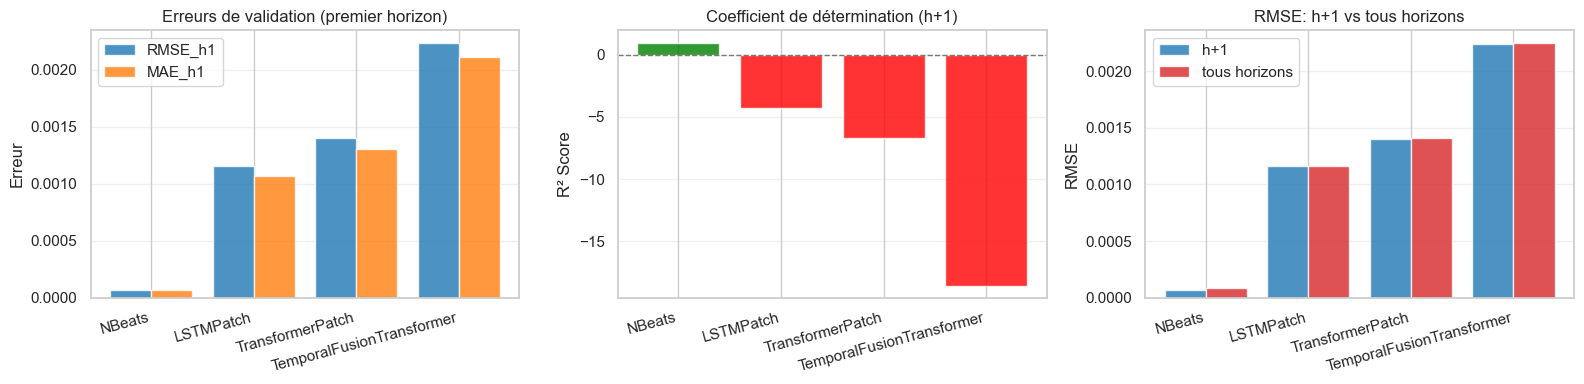

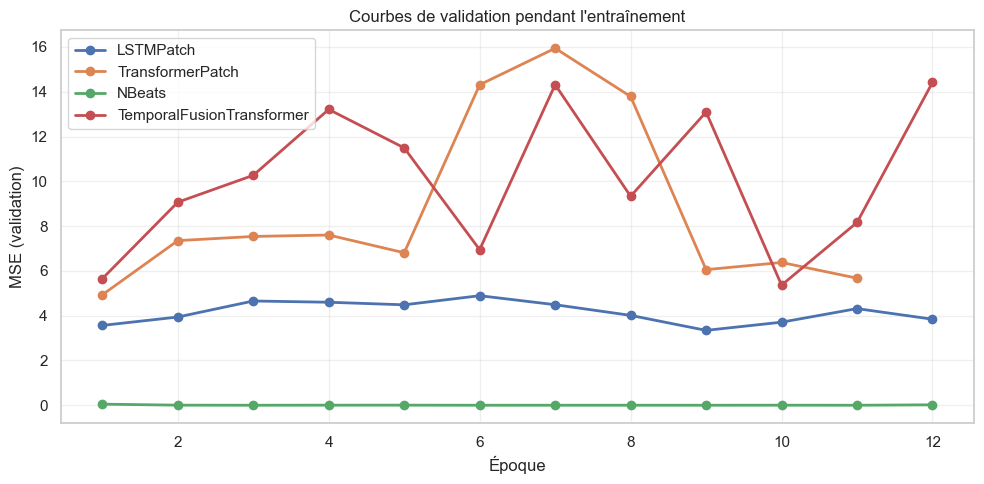

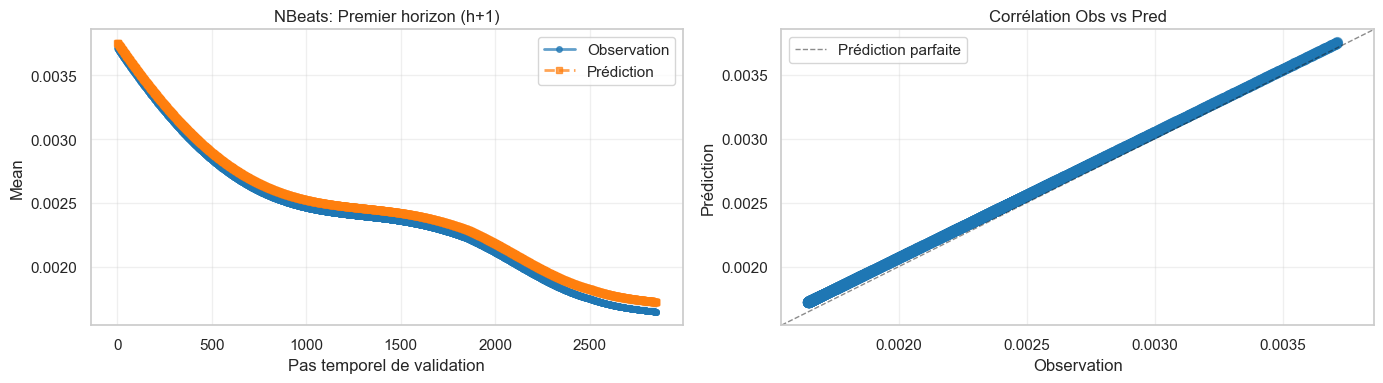

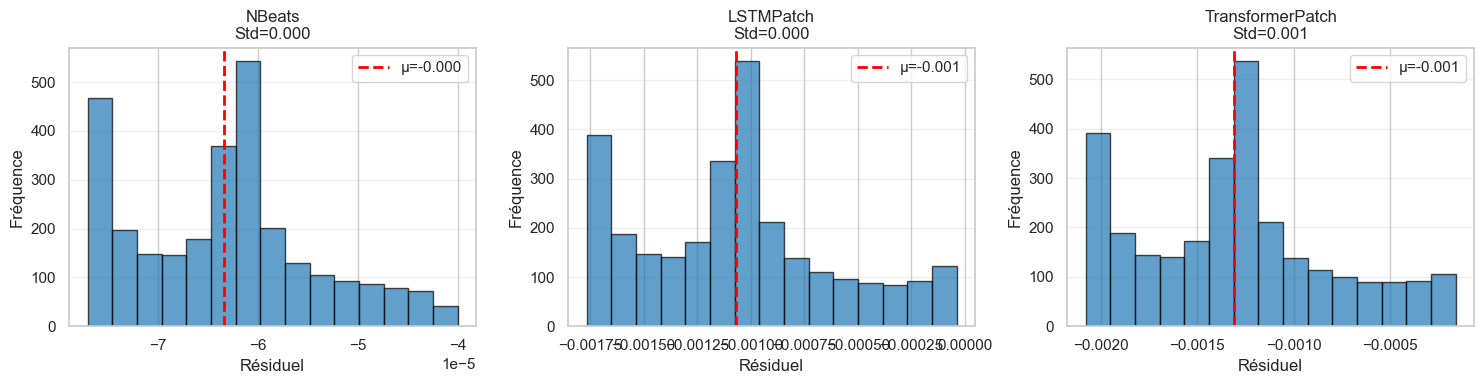


                       MEILLEUR MODÈLE: NBeats                        
 Model   MAE_h1  RMSE_h1    R2_h1  MAE_all  RMSE_all   R2_all
NBeats 0.000063 0.000064 0.983969 0.000079  0.000081 0.974274


In [12]:
if not results_df.empty:
    # === Figure 1: Comparaison des erreurs ===
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Barre RMSE et MAE
    x_pos = np.arange(len(results_df))
    ax = axes[0]
    ax.bar(x_pos - 0.2, results_df['RMSE_h1'], width=0.4, label='RMSE_h1', alpha=0.8, color='tab:blue')
    ax.bar(x_pos + 0.2, results_df['MAE_h1'], width=0.4, label='MAE_h1', alpha=0.8, color='tab:orange')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('Erreur')
    ax.set_title('Erreurs de validation (premier horizon)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # R² comparison
    ax = axes[1]
    colors = ['green' if r2 > 0 else 'red' for r2 in results_df['R2_h1']]
    ax.bar(x_pos, results_df['R2_h1'], alpha=0.8, color=colors)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('R² Score')
    ax.set_title('Coefficient de détermination (h+1)')
    ax.grid(axis='y', alpha=0.3)
    
    # Comparaison multi-horizon
    ax = axes[2]
    x_pos_h = np.arange(len(results_df))
    ax.bar(x_pos_h - 0.2, results_df['RMSE_h1'], width=0.4, label='h+1', alpha=0.8, color='tab:blue')
    ax.bar(x_pos_h + 0.2, results_df['RMSE_all'], width=0.4, label='tous horizons', alpha=0.8, color='tab:red')
    ax.set_xticks(x_pos_h)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('RMSE')
    ax.set_title('RMSE: h+1 vs tous horizons')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # === Figure 2: Courbes d'entraînement ===
    fig, ax = plt.subplots(figsize=(10, 5))
    for model_name, history_df in training_histories.items():
        if not history_df.empty:
            ax.plot(history_df['epoch'], history_df['val_loss'], marker='o', label=model_name, linewidth=2)
    ax.set_xlabel('Époque')
    ax.set_ylabel('MSE (validation)')
    ax.set_title('Courbes de validation pendant l\'entraînement')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # === Figure 3: Prédictions vs Observations (meilleur modèle) ===
    best_model_name = results_df.iloc[0]['Model']
    best_plot_data = results_plots[best_model_name]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Série temporelle complète
    ax = axes[0]
    ax.plot(best_plot_data['time_idx'], best_plot_data['truth_h1'], 'o-', label='Observation', 
            color='tab:blue', alpha=0.7, linewidth=2, markersize=4)
    ax.plot(best_plot_data['time_idx'], best_plot_data['pred_h1'], 's--', label='Prédiction', 
            color='tab:orange', alpha=0.7, linewidth=2, markersize=4)
    ax.fill_between(best_plot_data['time_idx'], best_plot_data['truth_h1'], best_plot_data['pred_h1'], 
                     alpha=0.2, color='gray')
    ax.set_xlabel('Pas temporel de validation')
    ax.set_ylabel(freq_target_col)
    ax.set_title(f'{best_model_name}: Premier horizon (h+1)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Scatter plot
    ax = axes[1]
    ax.scatter(best_plot_data['truth_h1'], best_plot_data['pred_h1'], alpha=0.6, s=50, color='tab:blue')
    
    # Ligne de référence parfaite
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='Prédiction parfaite')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Observation')
    ax.set_ylabel('Prédiction')
    ax.set_title('Corrélation Obs vs Pred')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # === Figure 4: Distribution des erreurs ===
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for idx, model_name in enumerate(results_df['Model']):
        if model_name in results_plots:
            plot_data = results_plots[model_name]
            residuals = plot_data['truth_h1'] - plot_data['pred_h1']
            ax = axes[idx] if idx < 3 else None
            if ax is not None:
                ax.hist(residuals, bins=15, alpha=0.7, color='tab:blue', edgecolor='black')
                ax.axvline(x=residuals.mean(), color='red', linestyle='--', linewidth=2, label=f'μ={residuals.mean():.3f}')
                ax.set_xlabel('Résiduel')
                ax.set_ylabel('Fréquence')
                ax.set_title(f'{model_name}\nStd={residuals.std():.3f}')
                ax.legend()
                ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f'\n{"="*70}')
    print(f'{"MEILLEUR MODÈLE: " + best_model_name:^70}')
    print(f'{"="*70}')
    print(results_df[results_df['Model'] == best_model_name].to_string(index=False))
    
else:
    print('⚠ Aucun résultat de modèle séquentiel. Vérifier les données et configurations.')


Modèle utilisé pour l'auto-régression: NBeats
Nombre de pas futurs prédits: 1000


c:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,forecast_step,future_time,predicted_value,model
0,1,1970-01-01 00:00:00.000013001,0.001721,NBeats
1,2,1970-01-01 00:00:00.000013002,0.001742,NBeats
2,3,1970-01-01 00:00:00.000013003,0.001746,NBeats
3,4,1970-01-01 00:00:00.000013004,0.001754,NBeats
4,5,1970-01-01 00:00:00.000013005,0.001742,NBeats
5,6,1970-01-01 00:00:00.000013006,0.001751,NBeats
6,7,1970-01-01 00:00:00.000013007,0.001788,NBeats
7,8,1970-01-01 00:00:00.000013008,0.001810,NBeats
8,9,1970-01-01 00:00:00.000013009,0.001819,NBeats
9,10,1970-01-01 00:00:00.000013010,0.001831,NBeats


,forecast_step,future_time,predicted_value,model
990,991,1970-01-01 00:00:00.000013991,0.006862,NBeats
991,992,1970-01-01 00:00:00.000013992,0.006869,NBeats
992,993,1970-01-01 00:00:00.000013993,0.006872,NBeats
993,994,1970-01-01 00:00:00.000013994,0.006867,NBeats
994,995,1970-01-01 00:00:00.000013995,0.006869,NBeats
995,996,1970-01-01 00:00:00.000013996,0.006874,NBeats
996,997,1970-01-01 00:00:00.000013997,0.006864,NBeats
997,998,1970-01-01 00:00:00.000013998,0.006871,NBeats
998,999,1970-01-01 00:00:00.000013999,0.006874,NBeats
999,1000,1970-01-01 00:00:00.000014000,0.006869,NBeats


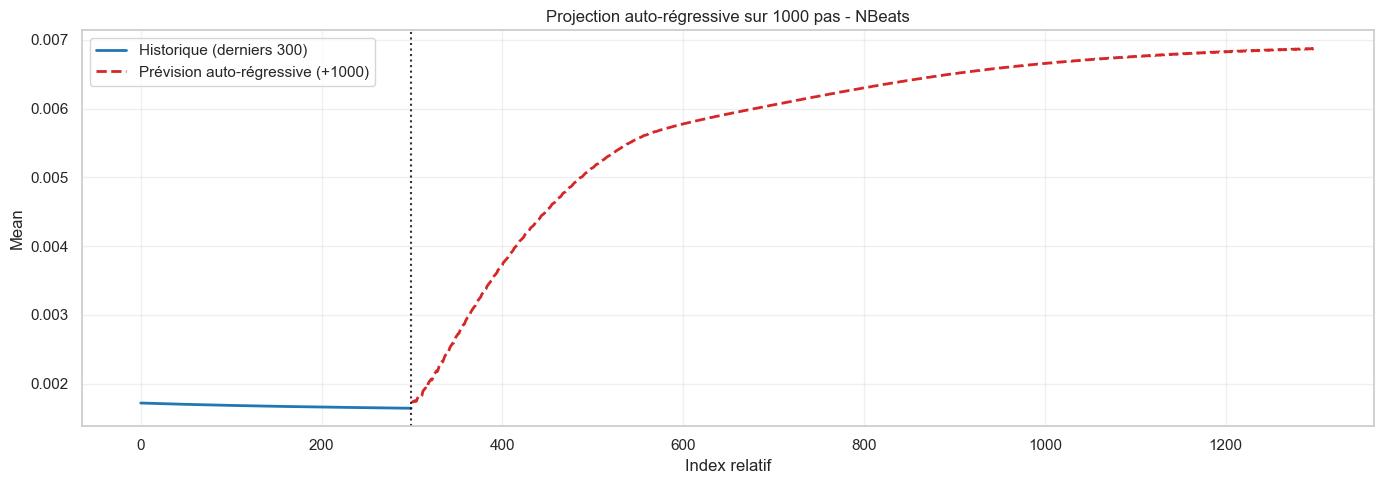

In [13]:
# === PRÉVISION AUTO-RÉGRESSIVE DES 1000 PROCHAINES VALEURS (HORS BASE) ===
# Cette cellule suppose que la section "modèles séquentiels fréquence" a déjà été exécutée.

AUTO_FUTURE_STEPS = 1000

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun résultat de modèle trouvé. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles.")
if 'freq_work' not in globals() or 'freq_target_col' not in globals() or 'target_scaler' not in globals():
    raise RuntimeError("Variables fréquence manquantes (freq_work, freq_target_col, target_scaler). Exécute la préparation des données fréquence.")

best_model_name = results_df.iloc[0]['Model']
if best_model_name not in trained_models:
    raise RuntimeError(f"Le meilleur modèle '{best_model_name}' n'est pas présent dans trained_models.")

best_model = trained_models[best_model_name].to(device)
best_model.eval()

# Série observée (échelle originale)
obs_values = pd.to_numeric(freq_work[freq_target_col], errors='coerce').interpolate(limit_direction='both').ffill().bfill().values.astype(float)

# Mise à l'échelle avec le scaler d'entraînement
obs_scaled = target_scaler.transform(obs_values.reshape(-1, 1)).reshape(-1).tolist()

if len(obs_scaled) < SEQ_INPUT_LEN:
    raise RuntimeError(f"Pas assez d'historique ({len(obs_scaled)}) pour SEQ_INPUT_LEN={SEQ_INPUT_LEN}.")

history_scaled = obs_scaled.copy()
future_scaled = []

# Auto-régression multi-horizon: à chaque boucle on prédit jusqu'à SEQ_HORIZON pas,
# puis on réinjecte ces prédictions comme nouvelles entrées.
with torch.no_grad():
    while len(future_scaled) < AUTO_FUTURE_STEPS:
        x_window = np.array(history_scaled[-SEQ_INPUT_LEN:], dtype=np.float32)
        x_tensor = torch.tensor(x_window, dtype=torch.float32, device=device).unsqueeze(0)  # (1, seq_len)

        y_hat = best_model(x_tensor).detach().cpu().numpy().reshape(-1)  # (pred_len,)

        remaining = AUTO_FUTURE_STEPS - len(future_scaled)
        chunk = y_hat[:remaining].tolist()
        future_scaled.extend(chunk)
        history_scaled.extend(chunk)

# Retour à l'échelle originale
future_values = target_scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1)).reshape(-1)

# Construction d'un axe temporel futur
if 'freq_time_col' in globals() and freq_time_col in freq_work.columns:
    time_series = freq_work[freq_time_col]

    # Cas datetime
    ts_datetime = pd.to_datetime(time_series, errors='coerce')
    if ts_datetime.notna().sum() >= 2:
        valid_dt = ts_datetime.dropna().sort_values().reset_index(drop=True)
        dt_diffs = valid_dt.diff().dropna()
        if len(dt_diffs) > 0:
            dt_step = dt_diffs.mode().iloc[0] if len(dt_diffs.mode()) > 0 else dt_diffs.median()
        else:
            dt_step = pd.Timedelta(days=1)
        last_time = valid_dt.iloc[-1]
        future_time = [last_time + (i + 1) * dt_step for i in range(AUTO_FUTURE_STEPS)]
    else:
        # Cas numérique
        ts_num = pd.to_numeric(time_series, errors='coerce')
        valid_num = ts_num.dropna().sort_values().reset_index(drop=True)
        if len(valid_num) >= 2:
            num_diffs = valid_num.diff().dropna()
            pos_diffs = num_diffs[num_diffs > 0]
            time_step = float(pos_diffs.median()) if len(pos_diffs) > 0 else 1.0
            last_time = float(valid_num.iloc[-1])
            future_time = [last_time + (i + 1) * time_step for i in range(AUTO_FUTURE_STEPS)]
        else:
            future_time = np.arange(len(obs_values), len(obs_values) + AUTO_FUTURE_STEPS)
else:
    future_time = np.arange(len(obs_values), len(obs_values) + AUTO_FUTURE_STEPS)

future_forecast_df = pd.DataFrame({
    'forecast_step': np.arange(1, AUTO_FUTURE_STEPS + 1),
    'future_time': future_time,
    'predicted_value': future_values,
    'model': best_model_name,
})

print(f"Modèle utilisé pour l'auto-régression: {best_model_name}")
print(f"Nombre de pas futurs prédits: {AUTO_FUTURE_STEPS}")
display(future_forecast_df.head(10))
display(future_forecast_df.tail(10))

# Visualisation: historique récent + projection future
recent_points = min(300, len(obs_values))
obs_recent = obs_values[-recent_points:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(np.arange(recent_points), obs_recent, color='tab:blue', linewidth=2, label=f'Historique (derniers {recent_points})')
ax.plot(np.arange(recent_points, recent_points + AUTO_FUTURE_STEPS), future_values,
        color='tab:red', linewidth=2, linestyle='--', label=f'Prévision auto-régressive (+{AUTO_FUTURE_STEPS})')
ax.axvline(recent_points - 1, color='black', linestyle=':', alpha=0.8)
ax.set_title(f"Projection auto-régressive sur {AUTO_FUTURE_STEPS} pas - {best_model_name}")
ax.set_xlabel('Index relatif')
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
import math
import torch
import torch.nn as nn


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class LSTMPatch(nn.Module):
    def __init__(self, input_dim=None, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, patch_size=4, hidden_dim=128, num_layers=2, dropout=0.2, **kwargs):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.patch_size = patch_size
        self.num_patches = max(1, seq_len // patch_size)
        self.patch_embedding = nn.Linear(patch_size, hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, pred_len),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        batch_size, seq_len, num_features = x.shape
        patch_len = self.patch_size
        n_patches = max(1, seq_len // patch_len)
        x = x[:, : n_patches * patch_len, :]
        x = x.reshape(batch_size, n_patches, patch_len * num_features)
        x = self.patch_embedding(x)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        return self.fc(x)


class TransformerPatch(nn.Module):
    def __init__(self, input_dim=None, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, patch_size=4, d_model=128, nhead=8, num_layers=3, dropout=0.1, dim_ff=512, **kwargs):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.patch_size = patch_size
        self.num_patches = max(1, seq_len // patch_size)
        self.patch_embedding = nn.Linear(patch_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            batch_first=True,
            dropout=dropout,
            activation='gelu',
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, pred_len),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        batch_size, seq_len, num_features = x.shape
        patch_len = self.patch_size
        n_patches = max(1, seq_len // patch_len)
        x = x[:, : n_patches * patch_len, :]
        x = x.reshape(batch_size, n_patches, patch_len * num_features)
        x = self.patch_embedding(x)
        x = self.pos_encoding(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1) + x[:, -1, :]
        return self.fc(x)


class NBeats(nn.Module):
    def __init__(self, input_dim=None, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, hidden_dim=256, num_blocks=3, num_layers=4, dropout=0.1, **kwargs):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        blocks = []
        for _ in range(num_blocks):
            layers = [nn.Linear(seq_len, hidden_dim), nn.ReLU(), nn.Dropout(dropout)]
            for _ in range(num_layers - 2):
                layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout)])
            layers.append(nn.Linear(hidden_dim, pred_len))
            blocks.append(nn.Sequential(*layers))
        self.blocks = nn.ModuleList(blocks)

    def forward(self, x):
        if x.dim() == 3:
            x = x.squeeze(-1)
        forecast = torch.zeros(x.size(0), self.pred_len, device=x.device)
        for block in self.blocks:
            forecast = forecast + block(x)
        return forecast


class TemporalFusionTransformer(nn.Module):
    def __init__(self, input_dim=None, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, d_model=128, nhead=8, num_layers=3, dropout=0.1, **kwargs):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.input_embed = nn.Linear(1, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            batch_first=True,
            dropout=dropout,
            activation='gelu',
        )
        self.temporal_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, pred_len),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        x = self.input_embed(x)
        x = self.pos_encoding(x)
        x = self.temporal_encoder(x)
        x = x.mean(dim=1)
        return self.decoder(x)


print('Modeles univaries redefinis pour accepter les entrees 2D et les configs existantes.')

Modeles univaries redefinis pour accepter les entrees 2D et les configs existantes.


## 13. Modeles sequentiels pour l'intensite

On applique exactement la meme logique que pour la frequence, mais en ne gardant que la colonne de temps et la colonne `mean` comme cible.

Mode univarié intensité: Temps + Mean uniquement
Table source: 13063 lignes / 5 colonnes
Colonne de temps: Age
Variable cible: Mean
Lignes exploitées: 13063


,Age,Mean
0,-62,0.688920
1,-61,0.688738
2,-60,0.688555
3,-59,0.688328
4,-58,0.688100


Fenetres train intensite: 10421 | Fenetres val intensite: 2613

           ENTRAÎNEMENT DES MODÈLES SÉQUENTIELS - INTENSITÉ           


>>> LSTMPATCH
----------------------------------------------------------------------
  Parametres: 282118
Epoch  1/12 | Train MSE: 0.072686 | Val MSE: 0.061531
Epoch  2/12 | Train MSE: 0.021489 | Val MSE: 0.181054
Epoch  4/12 | Train MSE: 0.016151 | Val MSE: 0.044754
Epoch  6/12 | Train MSE: 0.014647 | Val MSE: 0.072554
Epoch  8/12 | Train MSE: 0.013616 | Val MSE: 0.011796
Epoch 10/12 | Train MSE: 0.014176 | Val MSE: 0.147027
Epoch 12/12 | Train MSE: 0.013155 | Val MSE: 0.040695

  ✓ Performance (validation):
    RMSE (h+1): 0.0050
    MAE (h+1):  0.0034
    R² (h+1):   0.9680

>>> TRANSFORMERPATCH
----------------------------------------------------------------------
  Parametres: 612742
Epoch  1/12 | Train MSE: 0.062121 | Val MSE: 0.087173
Epoch  2/12 | Train MSE: 0.028676 | Val MSE: 0.352090
Epoch  4/12 | Train MSE: 0.022983 | Val MSE: 0.168622
Epo

,Model,MAE_h1,RMSE_h1,R2_h1,MAE_all,RMSE_all,R2_all
0,NBeats,0.002156,0.002330,0.993102,0.002140,0.002971,0.988721
1,TemporalFusionTransformer,0.003722,0.004620,0.972889,0.004462,0.005764,0.957528
2,LSTMPatch,0.003408,0.005023,0.967951,0.004830,0.006567,0.944875
3,TransformerPatch,0.008924,0.010188,0.868160,0.008574,0.010201,0.866995


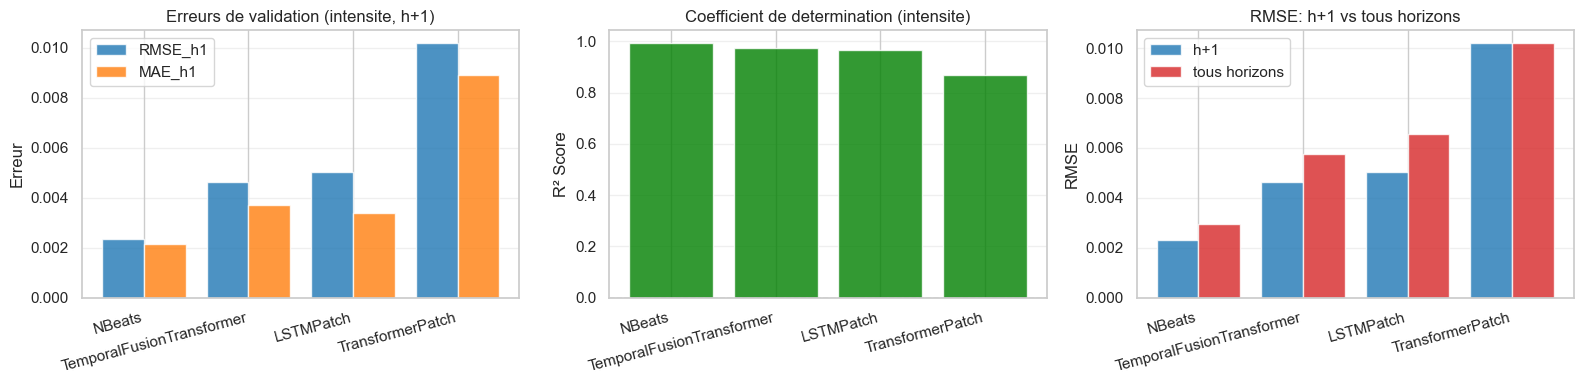

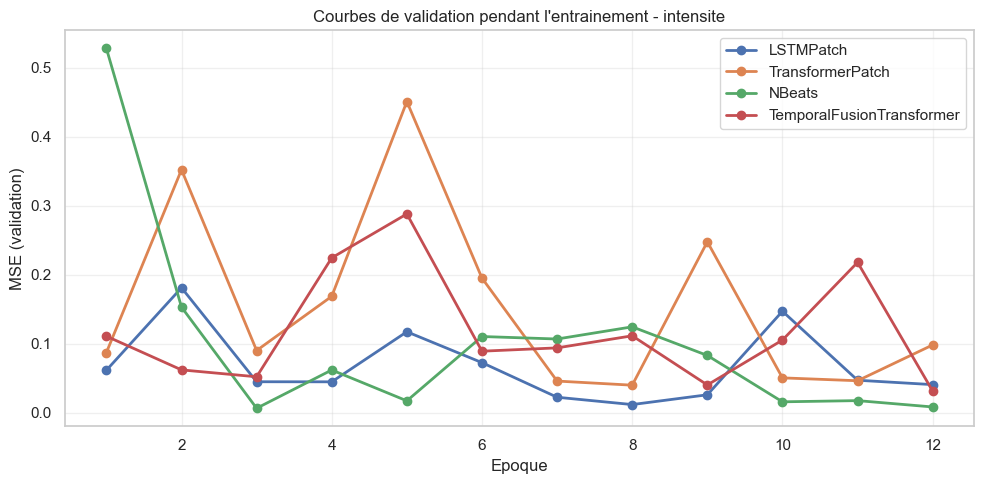

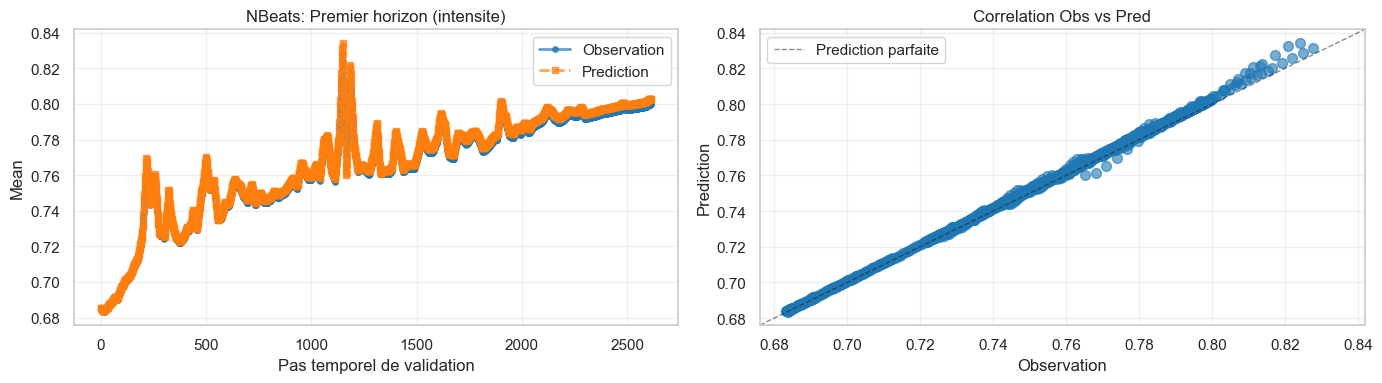


                  MEILLEUR MODÈLE INTENSITÉ: NBeats                   
 Model   MAE_h1  RMSE_h1    R2_h1  MAE_all  RMSE_all   R2_all
NBeats 0.002156  0.00233 0.993102  0.00214  0.002971 0.988721


In [15]:
# Preparation des donnees d'intensite: temps + mean uniquement
intensity_source_df = None
if 'intensity_df' in globals() and isinstance(intensity_df, pd.DataFrame):
    intensity_source_df = intensity_df.copy()
elif 'tables' in globals():
    intensity_table_name = next((name for name in INTENSITY_TABLE_PRIORITY if name in tables), None) if 'INTENSITY_TABLE_PRIORITY' in globals() else None
    if intensity_table_name is None:
        intensity_table_name = next(
            (
                name
                for name, df in tables.items()
                if find_first_matching_column(df, ['year', 'age', 'time', 'date', 'annee']) is not None
                and find_first_matching_column(df, ['mean']) is not None
            ),
            None,
        )
    if intensity_table_name is not None:
        intensity_source_df = tables[intensity_table_name].copy()

if intensity_source_df is None:
    raise RuntimeError('Impossible de construire la serie d\'intensite.')

intensity_time_col = (
    intensity_time_col
    if 'intensity_time_col' in globals() and intensity_time_col in intensity_source_df.columns
    else find_first_matching_column(intensity_source_df, ['year', 'age', 'time', 'date', 'annee'])
)
intensity_target_col = (
    intensity_target
    if 'intensity_target' in globals() and intensity_target in intensity_source_df.columns
    else find_first_matching_column(intensity_source_df, ['mean'])
)

if intensity_time_col is None:
    raise RuntimeError('Aucune colonne de temps exploitable n\'a ete trouvee pour l\'intensite.')
if intensity_target_col is None:
    raise RuntimeError('Aucune colonne mean n\'a ete trouvee pour l\'intensite.')

intensity_work = intensity_source_df[[intensity_time_col, intensity_target_col]].copy()
intensity_work[intensity_target_col] = pd.to_numeric(intensity_work[intensity_target_col], errors='coerce')
intensity_work = intensity_work.drop_duplicates().sort_values(intensity_time_col).reset_index(drop=True)
intensity_work[intensity_target_col] = (
    intensity_work[intensity_target_col]
    .interpolate(limit_direction='both')
    .ffill()
    .bfill()
)

print('Mode univarié intensité: Temps + Mean uniquement')
print(f'Table source: {intensity_source_df.shape[0]} lignes / {intensity_source_df.shape[1]} colonnes')
print(f'Colonne de temps: {intensity_time_col}')
print(f'Variable cible: {intensity_target_col}')
print(f'Lignes exploitées: {len(intensity_work)}')
display(intensity_work.head())

if len(intensity_work) < SEQ_INPUT_LEN + SEQ_HORIZON:
    raise RuntimeError('Pas assez de lignes pour construire les fenetres temporelles de l\'intensite.')

class UnivariateSequenceDataset(Dataset):
    """Dataset pour fenetres temporelles univariees."""
    def __init__(self, y_array, input_len=SEQ_INPUT_LEN, horizon=SEQ_HORIZON):
        self.y_array = y_array.astype(np.float32).flatten()
        self.input_len = input_len
        self.horizon = horizon

    def __len__(self):
        return max(0, len(self.y_array) - self.input_len - self.horizon + 1)

    def __getitem__(self, idx):
        x = self.y_array[idx : idx + self.input_len]
        y = self.y_array[idx + self.input_len : idx + self.input_len + self.horizon]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Split chronologique et mise a l'echelle
intensity_split_row = int(len(intensity_work) * (1 - VAL_FRACTION))
intensity_train_frame = intensity_work.iloc[:intensity_split_row].copy()
intensity_val_start = max(0, intensity_split_row - SEQ_INPUT_LEN - SEQ_HORIZON + 1)
intensity_val_frame = intensity_work.iloc[intensity_val_start:].copy()

intensity_target_scaler = StandardScaler()
intensity_train_y = intensity_target_scaler.fit_transform(intensity_train_frame[[intensity_target_col]])
intensity_val_y = intensity_target_scaler.transform(intensity_val_frame[[intensity_target_col]])

intensity_train_ds = UnivariateSequenceDataset(intensity_train_y)
intensity_val_ds = UnivariateSequenceDataset(intensity_val_y)
intensity_train_loader = DataLoader(intensity_train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
intensity_val_loader = DataLoader(intensity_val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Fenetres train intensite: {len(intensity_train_ds)} | Fenetres val intensite: {len(intensity_val_ds)}')

# Entrainement et evaluation
intensity_results_metrics = []
intensity_results_plots = {}
intensity_training_histories = {}
intensity_trained_models = {}

print(f'\n{"="*70}')
print(f'{"ENTRAÎNEMENT DES MODÈLES SÉQUENTIELS - INTENSITÉ":^70}')
print(f'{"="*70}\n')

for model_name, model_kwargs in MODEL_CONFIGS:
    print(f'\n>>> {model_name.upper()}')
    print(f'{"-"*70}')

    if model_name == 'LSTMPatch':
        model = LSTMPatch(**model_kwargs)
    elif model_name in ('TransformerPatch', 'PatchTST'):
        model = TransformerPatch(**model_kwargs)
    elif model_name == 'NBeats':
        model = NBeats(**model_kwargs)
    elif model_name == 'TemporalFusionTransformer':
        model = TemporalFusionTransformer(**model_kwargs)
    else:
        print(f'  ⚠ Modele {model_name} non reconnu.')
        continue

    print(f'  Parametres: {sum(p.numel() for p in model.parameters())}')

    model, history_df = fit_model(model, intensity_train_loader, intensity_val_loader, epochs=EPOCHS, lr=LEARNING_RATE, device=device)
    intensity_training_histories[model_name] = history_df
    intensity_trained_models[model_name] = model

    target_scaler = intensity_target_scaler
    preds, trues = predict_all(model, intensity_val_loader, device)
    metrics, plot_data = evaluate_model(preds, trues, model_name)

    if metrics is not None:
        intensity_results_metrics.append(metrics)
        intensity_results_plots[model_name] = plot_data
        print(f'\n  ✓ Performance (validation):')
        print(f'    RMSE (h+1): {metrics["RMSE_h1"]:.4f}')
        print(f'    MAE (h+1):  {metrics["MAE_h1"]:.4f}')
        print(f'    R² (h+1):   {metrics["R2_h1"]:.4f}')
    else:
        print('  ⚠ Aucune prediction exploitable.')

intensity_results_df = pd.DataFrame(intensity_results_metrics)
if not intensity_results_df.empty:
    intensity_results_df = intensity_results_df.sort_values('RMSE_h1').reset_index(drop=True)

print(f'\n\n{"="*70}')
print(f'{"RÉSUMÉ DES PERFORMANCES - INTENSITÉ":^70}')
print(f'{"="*70}\n')
display(intensity_results_df)

if not intensity_results_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    x_pos = np.arange(len(intensity_results_df))

    ax = axes[0]
    ax.bar(x_pos - 0.2, intensity_results_df['RMSE_h1'], width=0.4, label='RMSE_h1', alpha=0.8, color='tab:blue')
    ax.bar(x_pos + 0.2, intensity_results_df['MAE_h1'], width=0.4, label='MAE_h1', alpha=0.8, color='tab:orange')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(intensity_results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('Erreur')
    ax.set_title('Erreurs de validation (intensite, h+1)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    colors = ['green' if r2 > 0 else 'red' for r2 in intensity_results_df['R2_h1']]
    ax.bar(x_pos, intensity_results_df['R2_h1'], alpha=0.8, color=colors)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(intensity_results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('R² Score')
    ax.set_title('Coefficient de determination (intensite)')
    ax.grid(axis='y', alpha=0.3)

    ax = axes[2]
    ax.bar(x_pos - 0.2, intensity_results_df['RMSE_h1'], width=0.4, label='h+1', alpha=0.8, color='tab:blue')
    ax.bar(x_pos + 0.2, intensity_results_df['RMSE_all'], width=0.4, label='tous horizons', alpha=0.8, color='tab:red')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(intensity_results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('RMSE')
    ax.set_title('RMSE: h+1 vs tous horizons')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    for model_name, history_df in intensity_training_histories.items():
        if not history_df.empty:
            ax.plot(history_df['epoch'], history_df['val_loss'], marker='o', label=model_name, linewidth=2)
    ax.set_xlabel('Epoque')
    ax.set_ylabel('MSE (validation)')
    ax.set_title('Courbes de validation pendant l\'entrainement - intensite')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    best_model_name = intensity_results_df.iloc[0]['Model']
    best_plot_data = intensity_results_plots[best_model_name]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ax = axes[0]
    ax.plot(best_plot_data['time_idx'], best_plot_data['truth_h1'], 'o-', label='Observation', color='tab:blue', alpha=0.7, linewidth=2, markersize=4)
    ax.plot(best_plot_data['time_idx'], best_plot_data['pred_h1'], 's--', label='Prediction', color='tab:orange', alpha=0.7, linewidth=2, markersize=4)
    ax.fill_between(best_plot_data['time_idx'], best_plot_data['truth_h1'], best_plot_data['pred_h1'], alpha=0.2, color='gray')
    ax.set_xlabel('Pas temporel de validation')
    ax.set_ylabel(intensity_target_col)
    ax.set_title(f'{best_model_name}: Premier horizon (intensite)')
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    ax.scatter(best_plot_data['truth_h1'], best_plot_data['pred_h1'], alpha=0.6, s=50, color='tab:blue')
    lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='Prediction parfaite')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Observation')
    ax.set_ylabel('Prediction')
    ax.set_title('Correlation Obs vs Pred')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'\n{"="*70}')
    print(f'{"MEILLEUR MODÈLE INTENSITÉ: " + best_model_name:^70}')
    print(f'{"="*70}')
    print(intensity_results_df[intensity_results_df['Model'] == best_model_name].to_string(index=False))
else:
    print('⚠ Aucun resultat de modele sequentiel pour l\'intensite.')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_24588\2963408478.py:83: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,segment,n_points,MAE,RMSE,R2
0,autoregressive,1427.0,0.232025,0.240329,-297.742786
1,normal,1426.0,0.003093,0.003111,0.978806


,step,segment,truth_scaled,pred_scaled,truth,pred,residual
0,0,normal,-3.053257,-2.982647,0.544715,0.547014,-0.002299
1,1,normal,-3.057281,-2.986306,0.544584,0.546895,-0.002311
2,2,normal,-3.061308,-2.990141,0.544453,0.546770,-0.002317
3,3,normal,-3.063320,-2.994055,0.544388,0.546643,-0.002255
4,4,normal,-3.065333,-2.997684,0.544322,0.546525,-0.002202
5,5,normal,-3.069359,-3.001168,0.544191,0.546411,-0.002220
6,6,normal,-3.073384,-3.004634,0.544060,0.546298,-0.002238
7,7,normal,-3.077410,-3.008069,0.543929,0.546186,-0.002257
8,8,normal,-3.081425,-3.011641,0.543798,0.546070,-0.002272
9,9,normal,-3.085451,-3.015107,0.543667,0.545957,-0.002290


,step,segment,truth_scaled,pred_scaled,truth,pred,residual
2843,2843,autoregressive,-6.544726,2.092686,0.431053,0.712238,-0.281186
2844,2844,autoregressive,-6.545010,2.092688,0.431043,0.712238,-0.281195
2845,2845,autoregressive,-6.545294,2.092691,0.431034,0.712239,-0.281204
2846,2846,autoregressive,-6.545585,2.092693,0.431025,0.712239,-0.281214
2847,2847,autoregressive,-6.545877,2.092695,0.431015,0.712239,-0.281223
2848,2848,autoregressive,-6.546159,2.092697,0.431006,0.712239,-0.281233
2849,2849,autoregressive,-6.546442,2.092699,0.430997,0.712239,-0.281242
2850,2850,autoregressive,-6.546724,2.092701,0.430988,0.712239,-0.281251
2851,2851,autoregressive,-6.547008,2.092703,0.430978,0.712239,-0.281260
2852,2852,autoregressive,-6.547290,2.092705,0.430969,0.712239,-0.281270


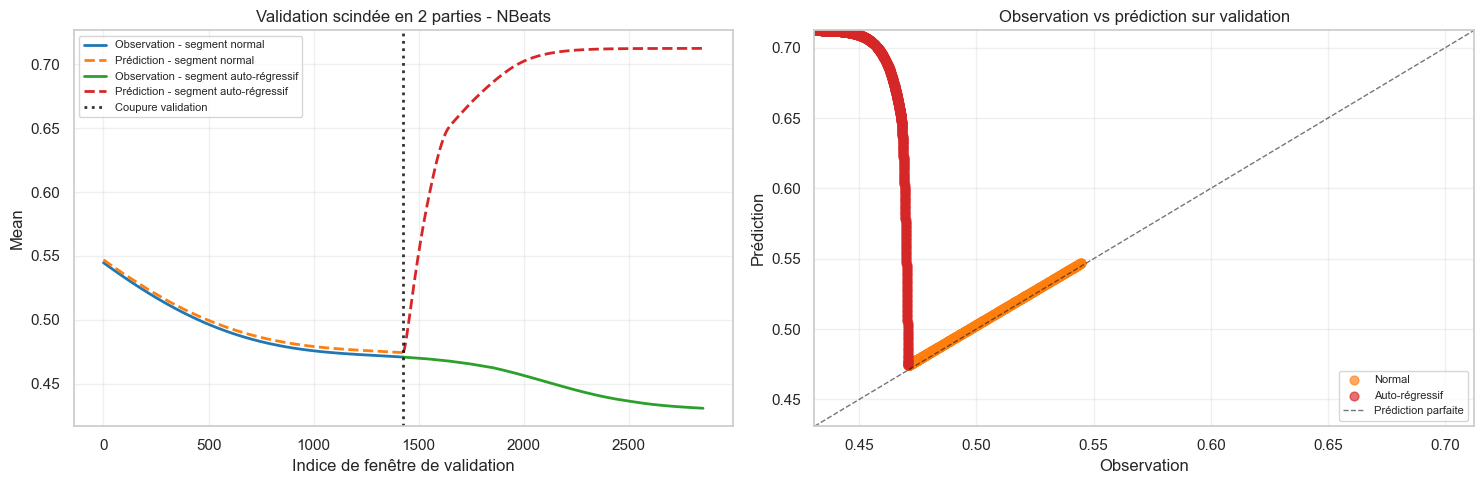

Modèle utilisé: NBeats
Fenêtres validation totales: 2853
Coupure entre les deux segments: fenêtre 1426


In [16]:
# === VALIDATION COMPARATIVE: PREMIERE MOITIE NORMALE, SECONDE MOITIE AUTO-REGRESSIVE ===
# Cette cellule suppose que la section fréquence a déjà été exécutée
# et que results_df, trained_models, freq_work, freq_target_col, target_scaler, val_frame existent.

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun résultat de modèle trouvé. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles.")
if 'freq_work' not in globals() or 'freq_target_col' not in globals() or 'target_scaler' not in globals():
    raise RuntimeError("Variables fréquence manquantes. Exécute d'abord la préparation des données fréquence.")
if 'val_frame' not in globals():
    raise RuntimeError("val_frame est manquant. Exécute d'abord le split train/validation.")

best_model_name = results_df.iloc[0]['Model']
if best_model_name not in trained_models:
    raise RuntimeError(f"Le meilleur modèle '{best_model_name}' n'est pas présent dans trained_models.")

best_model = trained_models[best_model_name].to(device)
best_model.eval()

validation_scaled = np.asarray(val_y if 'val_y' in globals() else target_scaler.transform(val_frame[[freq_target_col]]), dtype=np.float32).reshape(-1)
validation_original = pd.to_numeric(val_frame[freq_target_col], errors='coerce').interpolate(limit_direction='both').ffill().bfill().values.astype(float)

if len(validation_scaled) < SEQ_INPUT_LEN + 2:
    raise RuntimeError("Pas assez de points de validation pour faire une coupure en deux segments.")

# Nombre de fenêtres exploitables dans la validation
n_windows = len(validation_scaled) - SEQ_INPUT_LEN - SEQ_HORIZON + 1
if n_windows <= 1:
    raise RuntimeError("La validation ne contient pas assez de fenêtres pour faire une comparaison en deux segments.")

split_window = n_windows // 2

# On compare uniquement le premier horizon (h+1) pour garder un alignement simple observation/prediction.
# Segment 1: prédiction normale (fenêtres qui utilisent encore les vraies valeurs de validation)
# Segment 2: prédiction auto-régressive (les prédictions réinjectées dans l'entrée)

def predict_h1_from_window(model, window_scaled):
    x_tensor = torch.tensor(np.asarray(window_scaled, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        pred = model(x_tensor).detach().cpu().numpy().reshape(-1)
    return float(pred[0])

# Segment normal
normal_steps = []
normal_truth = []
normal_pred = []
for i in range(split_window):
    window = validation_scaled[i : i + SEQ_INPUT_LEN]
    truth_idx = i + SEQ_INPUT_LEN
    normal_steps.append(i)
    normal_truth.append(validation_scaled[truth_idx])
    normal_pred.append(predict_h1_from_window(best_model, window))

# Segment auto-régressif
ar_steps = []
ar_truth = []
ar_pred = []

# Historique initial: on part des vraies valeurs jusqu'au début de la seconde moitié
history = validation_scaled[: split_window + SEQ_INPUT_LEN].tolist()
for step in range(split_window, n_windows):
    window = history[-SEQ_INPUT_LEN:]
    truth_idx = step + SEQ_INPUT_LEN
    ar_steps.append(step)
    ar_truth.append(validation_scaled[truth_idx])
    pred_value = predict_h1_from_window(best_model, window)
    ar_pred.append(pred_value)
    history.append(pred_value)

comparison_df = pd.DataFrame({
    'step': normal_steps + ar_steps,
    'segment': ['normal'] * len(normal_steps) + ['autoregressive'] * len(ar_steps),
    'truth_scaled': normal_truth + ar_truth,
    'pred_scaled': normal_pred + ar_pred,
})
comparison_df['truth'] = target_scaler.inverse_transform(comparison_df[['truth_scaled']]).reshape(-1)
comparison_df['pred'] = target_scaler.inverse_transform(comparison_df[['pred_scaled']]).reshape(-1)
comparison_df['residual'] = comparison_df['truth'] - comparison_df['pred']

segment_summary = (
    comparison_df.groupby('segment')
    .apply(lambda g: pd.Series({
        'n_points': len(g),
        'MAE': mean_absolute_error(g['truth'], g['pred']),
        'RMSE': float(np.sqrt(mean_squared_error(g['truth'], g['pred']))),
        'R2': r2_score(g['truth'], g['pred']) if len(g) > 1 else np.nan,
    }))
    .reset_index()
)

display(segment_summary)
display(comparison_df.head(10))
display(comparison_df.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Courbe observation vs prédiction, avec séparation visuelle des deux segments
ax = axes[0]
normal_df = comparison_df[comparison_df['segment'] == 'normal']
ar_df = comparison_df[comparison_df['segment'] == 'autoregressive']

ax.plot(normal_df['step'], normal_df['truth'], color='tab:blue', linewidth=2, label='Observation - segment normal')
ax.plot(normal_df['step'], normal_df['pred'], color='tab:orange', linewidth=2, linestyle='--', label='Prédiction - segment normal')
ax.plot(ar_df['step'], ar_df['truth'], color='tab:green', linewidth=2, label='Observation - segment auto-régressif')
ax.plot(ar_df['step'], ar_df['pred'], color='tab:red', linewidth=2, linestyle='--', label='Prédiction - segment auto-régressif')
ax.axvline(split_window - 0.5, color='black', linestyle=':', linewidth=2, alpha=0.8, label='Coupure validation')
ax.set_title(f"Validation scindée en 2 parties - {best_model_name}")
ax.set_xlabel('Indice de fenêtre de validation')
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# Scatter observation vs prédiction, coloré par segment
ax = axes[1]
ax.scatter(normal_df['truth'], normal_df['pred'], color='tab:orange', alpha=0.65, s=40, label='Normal')
ax.scatter(ar_df['truth'], ar_df['pred'], color='tab:red', alpha=0.65, s=40, label='Auto-régressif')
lims = [
    np.nanmin([comparison_df['truth'].min(), comparison_df['pred'].min()]),
    np.nanmax([comparison_df['truth'].max(), comparison_df['pred'].max()]),
]
ax.plot(lims, lims, 'k--', alpha=0.6, linewidth=1, label='Prédiction parfaite')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title('Observation vs prédiction sur validation')
ax.set_xlabel('Observation')
ax.set_ylabel('Prédiction')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Modèle utilisé: {best_model_name}")
print(f"Fenêtres validation totales: {n_windows}")
print(f"Coupure entre les deux segments: fenêtre {split_window}")

,model,n_validation_windows,reference_window,control_window,baseline_mae,baseline_rmse,acceptable_factor,last_acceptable_step,last_acceptable_percent
0,NBeats,2853,20,20,0.006778,0.007532,1.5,24,0.84


,step,truth_scaled,pred_scaled,truth,pred,abs_error,sq_error,rolling_mae,rolling_rmse,acceptable
0,0,-3.053257,-2.982647,0.544715,0.547014,0.002299,0.000005,NaN,NaN,False
1,1,-3.057281,-2.977144,0.544584,0.547193,0.002609,0.000007,NaN,NaN,False
2,2,-3.061308,-2.970290,0.544453,0.547416,0.002963,0.000009,NaN,NaN,False
3,3,-3.063320,-2.962534,0.544388,0.547669,0.003281,0.000011,NaN,NaN,False
4,4,-3.065333,-2.956579,0.544322,0.547863,0.003540,0.000013,NaN,NaN,False
5,5,-3.069359,-2.948779,0.544191,0.548117,0.003925,0.000015,NaN,NaN,False
6,6,-3.073384,-2.937822,0.544060,0.548473,0.004413,0.000019,NaN,NaN,False
7,7,-3.077410,-2.926988,0.543929,0.548826,0.004897,0.000024,NaN,NaN,False
8,8,-3.081425,-2.914323,0.543798,0.549238,0.005440,0.000030,NaN,NaN,False
9,9,-3.085451,-2.900131,0.543667,0.549700,0.006033,0.000036,NaN,NaN,False


,step,truth_scaled,pred_scaled,truth,pred,abs_error,sq_error,rolling_mae,rolling_rmse,acceptable
2843,2843,-6.544726,2.09295,0.431053,0.712247,0.281194,0.079070,0.281106,0.281106,False
2844,2844,-6.545010,2.09295,0.431043,0.712247,0.281203,0.079075,0.281115,0.281115,False
2845,2845,-6.545294,2.09295,0.431034,0.712247,0.281213,0.079081,0.281124,0.281124,False
2846,2846,-6.545585,2.09295,0.431025,0.712247,0.281222,0.079086,0.281134,0.281134,False
2847,2847,-6.545877,2.09295,0.431015,0.712247,0.281232,0.079091,0.281143,0.281143,False
2848,2848,-6.546159,2.09295,0.431006,0.712247,0.281241,0.079096,0.281152,0.281152,False
2849,2849,-6.546442,2.09295,0.430997,0.712247,0.281250,0.079102,0.281162,0.281162,False
2850,2850,-6.546724,2.09295,0.430988,0.712247,0.281259,0.079107,0.281171,0.281171,False
2851,2851,-6.547008,2.09295,0.430978,0.712247,0.281268,0.079112,0.281180,0.281180,False
2852,2852,-6.547290,2.09295,0.430969,0.712247,0.281278,0.079117,0.281190,0.281190,False


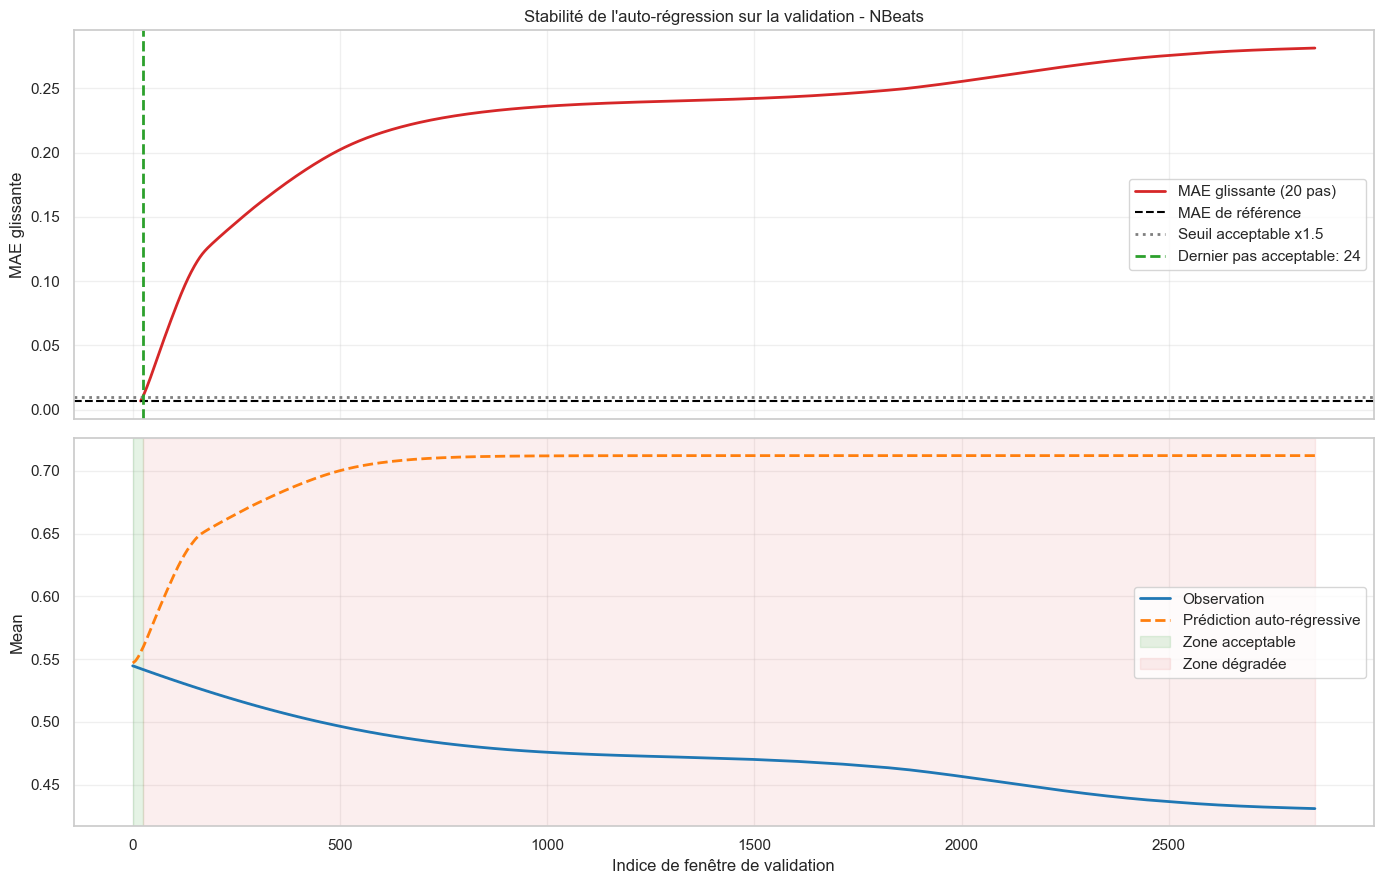

Dernier pas jugé acceptable: 24 sur 2852
Cela correspond approximativement à 0.8% de la validation.
Référence: MAE=0.0068, seuil=0.0102


In [17]:
# === JUSQU'OÙ L'AUTO-RÉGRESSION RESTE ACCEPTABLE SUR LA VALIDATION ? ===
# Objectif: parcourir la validation du début à la fin et repérer le point où
# la prédiction auto-régressive commence à se dégrader de façon notable.
#
# Définition de l'acceptabilité ci-dessous:
# - on calcule une erreur absolue glissante sur une fenêtre de contrôle,
# - on compare cette erreur à une référence issue du segment initial normal,
# - on repère le dernier pas où l'erreur reste sous un seuil relatif.

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun résultat de modèle trouvé. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles.")
if 'freq_work' not in globals() or 'freq_target_col' not in globals() or 'target_scaler' not in globals():
    raise RuntimeError("Variables fréquence manquantes. Exécute d'abord la préparation des données fréquence.")
if 'val_frame' not in globals():
    raise RuntimeError("val_frame est manquant. Exécute d'abord le split train/validation.")

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name].to(device)
best_model.eval()

validation_scaled = np.asarray(
    val_y if 'val_y' in globals() else target_scaler.transform(val_frame[[freq_target_col]]),
    dtype=np.float32,
).reshape(-1)
validation_values = pd.to_numeric(val_frame[freq_target_col], errors='coerce').interpolate(limit_direction='both').ffill().bfill().values.astype(float)

if len(validation_scaled) < SEQ_INPUT_LEN + SEQ_HORIZON + 5:
    raise RuntimeError("Pas assez de points de validation pour analyser correctement l'auto-régression.")

n_windows = len(validation_scaled) - SEQ_INPUT_LEN - SEQ_HORIZON + 1
if n_windows <= 3:
    raise RuntimeError("Validation trop courte pour une analyse de stabilité auto-régressive.")

def predict_h1(model, window_scaled):
    x_tensor = torch.tensor(np.asarray(window_scaled, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return float(model(x_tensor).detach().cpu().numpy().reshape(-1)[0])

# Générer la prédiction auto-régressive complète sur toute la validation (h+1)
history = validation_scaled[:SEQ_INPUT_LEN].tolist()
ar_truth_scaled = []
ar_pred_scaled = []
for step in range(n_windows):
    truth_idx = step + SEQ_INPUT_LEN
    ar_truth_scaled.append(validation_scaled[truth_idx])
    pred_value = predict_h1(best_model, history[-SEQ_INPUT_LEN:])
    ar_pred_scaled.append(pred_value)
    history.append(pred_value)

ar_df = pd.DataFrame({
    'step': np.arange(n_windows),
    'truth_scaled': ar_truth_scaled,
    'pred_scaled': ar_pred_scaled,
})
ar_df['truth'] = target_scaler.inverse_transform(ar_df[['truth_scaled']]).reshape(-1)
ar_df['pred'] = target_scaler.inverse_transform(ar_df[['pred_scaled']]).reshape(-1)
ar_df['abs_error'] = (ar_df['truth'] - ar_df['pred']).abs()
ar_df['sq_error'] = (ar_df['truth'] - ar_df['pred']) ** 2

# Référence de qualité prise sur le début de la validation, où l'auto-régression est la plus proche du réel
REFERENCE_WINDOW = min(20, max(5, n_windows // 10))
CONTROL_WINDOW = min(20, max(5, n_windows // 10))

baseline_mae = ar_df.loc[:REFERENCE_WINDOW - 1, 'abs_error'].mean()
baseline_rmse = float(np.sqrt(ar_df.loc[:REFERENCE_WINDOW - 1, 'sq_error'].mean()))

# Seuil d'acceptabilité: erreur glissante <= FACTEUR_ACCEPTABLE * erreur de référence
FACTEUR_ACCEPTABLE = 1.5

ar_df['rolling_mae'] = ar_df['abs_error'].rolling(window=CONTROL_WINDOW, min_periods=CONTROL_WINDOW).mean()
ar_df['rolling_rmse'] = np.sqrt(ar_df['sq_error'].rolling(window=CONTROL_WINDOW, min_periods=CONTROL_WINDOW).mean())
ar_df['acceptable'] = ar_df['rolling_mae'] <= (FACTEUR_ACCEPTABLE * baseline_mae)

acceptable_idx = ar_df.index[ar_df['acceptable']].to_list()
if acceptable_idx:
    last_acceptable_step = int(ar_df.loc[acceptable_idx[-1], 'step'])
else:
    last_acceptable_step = None

summary = pd.DataFrame([
    {
        'model': best_model_name,
        'n_validation_windows': n_windows,
        'reference_window': REFERENCE_WINDOW,
        'control_window': CONTROL_WINDOW,
        'baseline_mae': baseline_mae,
        'baseline_rmse': baseline_rmse,
        'acceptable_factor': FACTEUR_ACCEPTABLE,
        'last_acceptable_step': last_acceptable_step,
        'last_acceptable_percent': None if last_acceptable_step is None else round(100 * last_acceptable_step / (n_windows - 1), 2),
    }
])

display(summary)
display(ar_df.head(10))
display(ar_df.tail(10))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Courbe des erreurs glissantes avec seuil d'acceptabilité
ax = axes[0]
ax.plot(ar_df['step'], ar_df['rolling_mae'], color='tab:red', linewidth=2, label=f'MAE glissante ({CONTROL_WINDOW} pas)')
ax.axhline(baseline_mae, color='black', linestyle='--', linewidth=1.5, label='MAE de référence')
ax.axhline(FACTEUR_ACCEPTABLE * baseline_mae, color='tab:gray', linestyle=':', linewidth=2, label=f'Seuil acceptable x{FACTEUR_ACCEPTABLE}')
if last_acceptable_step is not None:
    ax.axvline(last_acceptable_step, color='tab:green', linestyle='--', linewidth=2, label=f'Dernier pas acceptable: {last_acceptable_step}')
ax.set_title(f"Stabilité de l'auto-régression sur la validation - {best_model_name}")
ax.set_ylabel('MAE glissante')
ax.grid(alpha=0.3)
ax.legend()

# Courbe observation vs prédiction avec zone acceptable colorée
ax = axes[1]
ax.plot(ar_df['step'], ar_df['truth'], color='tab:blue', linewidth=2, label='Observation')
ax.plot(ar_df['step'], ar_df['pred'], color='tab:orange', linewidth=2, linestyle='--', label='Prédiction auto-régressive')
if last_acceptable_step is not None:
    ax.axvspan(0, last_acceptable_step, color='tab:green', alpha=0.12, label='Zone acceptable')
    ax.axvspan(last_acceptable_step, n_windows - 1, color='tab:red', alpha=0.08, label='Zone dégradée')
ax.set_xlabel('Indice de fenêtre de validation')
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

if last_acceptable_step is None:
    print('Aucune zone auto-régressive clairement acceptable selon le seuil actuel.')
else:
    print(f"Dernier pas jugé acceptable: {last_acceptable_step} sur {n_windows - 1}")
    print(f"Cela correspond approximativement à {100 * last_acceptable_step / (n_windows - 1):.1f}% de la validation.")
    print(f"Référence: MAE={baseline_mae:.4f}, seuil={FACTEUR_ACCEPTABLE * baseline_mae:.4f}")

,model,start_window,input_years,output_years,total_years,MAE_output,RMSE_output,R2_output
0,NBeats,1426,24,6,30,0.004318,0.00434,-47654.878906


,position,part,time,actual
0,0,input,11586.0,0.002377
1,1,input,11587.0,0.002377
2,2,input,11588.0,0.002377
3,3,input,11589.0,0.002376
4,4,input,11590.0,0.002376
5,5,input,11591.0,0.002376
6,6,input,11592.0,0.002376
7,7,input,11593.0,0.002376
8,8,input,11594.0,0.002375
9,9,input,11594.5,0.002375


,step_ahead,time,actual,predicted,residual
0,1,11608.0,0.470975,0.474414,-0.003439
1,2,11609.0,0.470964,0.475259,-0.004295
2,3,11610.0,0.470952,0.475314,-0.004362
3,4,11611.0,0.470941,0.475701,-0.004760
4,5,11612.0,0.470929,0.475307,-0.004379
5,6,11613.0,0.470917,0.475594,-0.004676


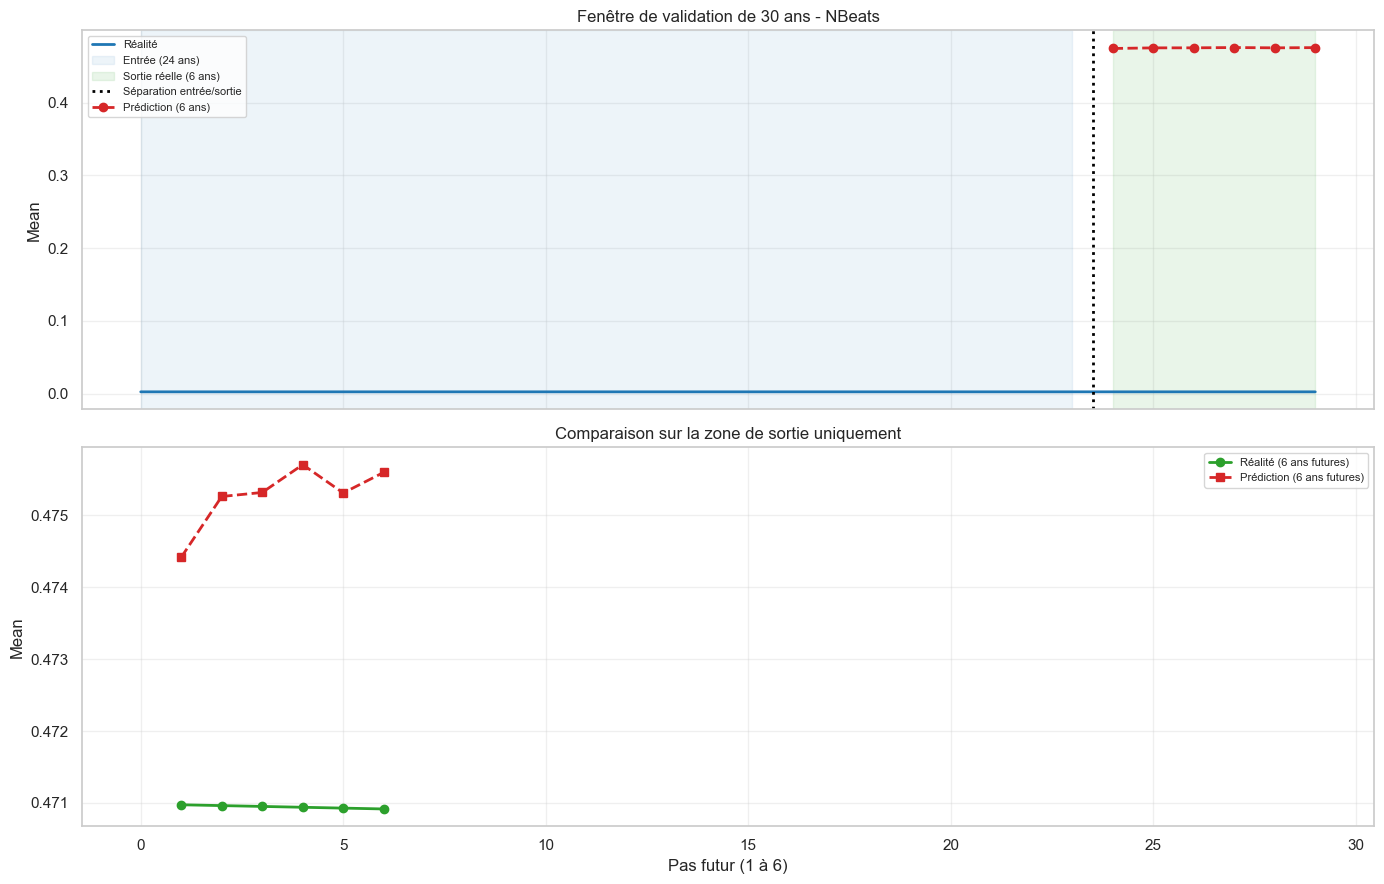

Modèle utilisé: NBeats
Fenêtre choisie: 1426 -> 1455
Entrée: 24 ans | Sortie: 6 ans | Total: 30 ans
MAE sur les 6 années de sortie: 0.0043
RMSE sur les 6 années de sortie: 0.0043


In [18]:
# === FENÊTRE DE VALIDATION DE 30 ANS: 24 ANNÉES D'ENTRÉE + 6 ANNÉES DE SORTIE ===
# But: prendre un segment unique de validation, distinguer la partie entrée (24 ans)
# et la partie sortie (6 ans), puis comparer réalité et prédiction sur ces 30 ans.

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun résultat de modèle trouvé. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles.")
if 'freq_work' not in globals() or 'freq_target_col' not in globals() or 'target_scaler' not in globals():
    raise RuntimeError("Variables fréquence manquantes. Exécute d'abord la préparation des données fréquence.")
if 'val_frame' not in globals():
    raise RuntimeError("val_frame est manquant. Exécute d'abord le split train/validation.")

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name].to(device)
best_model.eval()

validation_scaled = np.asarray(
    val_y if 'val_y' in globals() else target_scaler.transform(val_frame[[freq_target_col]]),
    dtype=np.float32,
).reshape(-1)
validation_values = pd.to_numeric(val_frame[freq_target_col], errors='coerce').interpolate(limit_direction='both').ffill().bfill().values.astype(float)

# Fenêtre demandée: 24 ans d'entrée + 6 ans de sortie = 30 ans
WINDOW_INPUT = 24
WINDOW_OUTPUT = 6
WINDOW_TOTAL = WINDOW_INPUT + WINDOW_OUTPUT

if len(validation_scaled) < WINDOW_TOTAL:
    raise RuntimeError(f"Pas assez de points de validation pour construire une fenêtre de {WINDOW_TOTAL} ans.")

# Choix d'une fenêtre 'quelconque' au milieu de la validation, mais ajustable
START_WINDOW = max(0, min(len(validation_scaled) - WINDOW_TOTAL, len(validation_scaled) // 2 - WINDOW_TOTAL // 2))
END_WINDOW = START_WINDOW + WINDOW_TOTAL

segment_scaled = validation_scaled[START_WINDOW:END_WINDOW]
segment_values = validation_values[START_WINDOW:END_WINDOW]

input_scaled = segment_scaled[:WINDOW_INPUT]
true_future_scaled = segment_scaled[WINDOW_INPUT:WINDOW_TOTAL]

x_tensor = torch.tensor(input_scaled, dtype=torch.float32, device=device).unsqueeze(0)
with torch.no_grad():
    pred_scaled = best_model(x_tensor).detach().cpu().numpy().reshape(-1)

pred_horizon_scaled = pred_scaled[:WINDOW_OUTPUT]

# Revenir à l'échelle originale
segment_input = target_scaler.inverse_transform(input_scaled.reshape(-1, 1)).reshape(-1)
segment_future_true = target_scaler.inverse_transform(true_future_scaled.reshape(-1, 1)).reshape(-1)
segment_future_pred = target_scaler.inverse_transform(pred_horizon_scaled.reshape(-1, 1)).reshape(-1)

# Date / index pour l'axe X
if 'freq_time_col' in globals() and freq_time_col in val_frame.columns:
    seg_time = val_frame[freq_time_col].iloc[START_WINDOW:END_WINDOW].reset_index(drop=True)
else:
    seg_time = np.arange(START_WINDOW, END_WINDOW)

comparison_segment_df = pd.DataFrame({
    'position': np.arange(WINDOW_TOTAL),
    'part': ['input'] * WINDOW_INPUT + ['output'] * WINDOW_OUTPUT,
    'time': seg_time,
    'actual': segment_values,
})
comparison_future_df = pd.DataFrame({
    'step_ahead': np.arange(1, WINDOW_OUTPUT + 1),
    'time': seg_time.iloc[WINDOW_INPUT:].reset_index(drop=True) if hasattr(seg_time, 'iloc') else seg_time[WINDOW_INPUT:],
    'actual': segment_future_true,
    'predicted': segment_future_pred,
    'residual': segment_future_true - segment_future_pred,
})

segment_mae = mean_absolute_error(segment_future_true, segment_future_pred)
segment_rmse = float(np.sqrt(mean_squared_error(segment_future_true, segment_future_pred)))
segment_r2 = r2_score(segment_future_true, segment_future_pred) if len(segment_future_true) > 1 else np.nan

summary_segment = pd.DataFrame([
    {
        'model': best_model_name,
        'start_window': START_WINDOW,
        'input_years': WINDOW_INPUT,
        'output_years': WINDOW_OUTPUT,
        'total_years': WINDOW_TOTAL,
        'MAE_output': segment_mae,
        'RMSE_output': segment_rmse,
        'R2_output': segment_r2,
    }
])

display(summary_segment)
display(comparison_segment_df)
display(comparison_future_df)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Courbe sur 30 ans, avec séparation entrée / sortie
ax = axes[0]
ax.plot(comparison_segment_df['position'], comparison_segment_df['actual'], color='tab:blue', linewidth=2, label='Réalité')
ax.axvspan(0, WINDOW_INPUT - 1, color='tab:blue', alpha=0.08, label='Entrée (24 ans)')
ax.axvspan(WINDOW_INPUT, WINDOW_TOTAL - 1, color='tab:green', alpha=0.10, label='Sortie réelle (6 ans)')
ax.axvline(WINDOW_INPUT - 0.5, color='black', linestyle=':', linewidth=2, label='Séparation entrée/sortie')
ax.plot(np.arange(WINDOW_INPUT, WINDOW_TOTAL), segment_future_pred, color='tab:red', linestyle='--', marker='o', linewidth=2, label='Prédiction (6 ans)')
ax.set_title(f"Fenêtre de validation de 30 ans - {best_model_name}")
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# Zoom sur les 6 années de sortie: réalité vs prédiction
ax = axes[1]
ax.plot(np.arange(1, WINDOW_OUTPUT + 1), segment_future_true, color='tab:green', linewidth=2, marker='o', label='Réalité (6 ans futures)')
ax.plot(np.arange(1, WINDOW_OUTPUT + 1), segment_future_pred, color='tab:red', linewidth=2, marker='s', linestyle='--', label='Prédiction (6 ans futures)')
ax.set_xlabel('Pas futur (1 à 6)')
ax.set_ylabel(freq_target_col)
ax.set_title('Comparaison sur la zone de sortie uniquement')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Modèle utilisé: {best_model_name}")
print(f"Fenêtre choisie: {START_WINDOW} -> {END_WINDOW - 1}")
print(f"Entrée: {WINDOW_INPUT} ans | Sortie: {WINDOW_OUTPUT} ans | Total: {WINDOW_TOTAL} ans")
print(f"MAE sur les 6 années de sortie: {segment_mae:.4f}")
print(f"RMSE sur les 6 années de sortie: {segment_rmse:.4f}")

,step,predicted_future,model
0,2882,0.435151,NBeats
1,2883,0.435708,NBeats
2,2884,0.436360,NBeats
3,2885,0.437027,NBeats
4,2886,0.437603,NBeats
5,2887,0.438315,NBeats


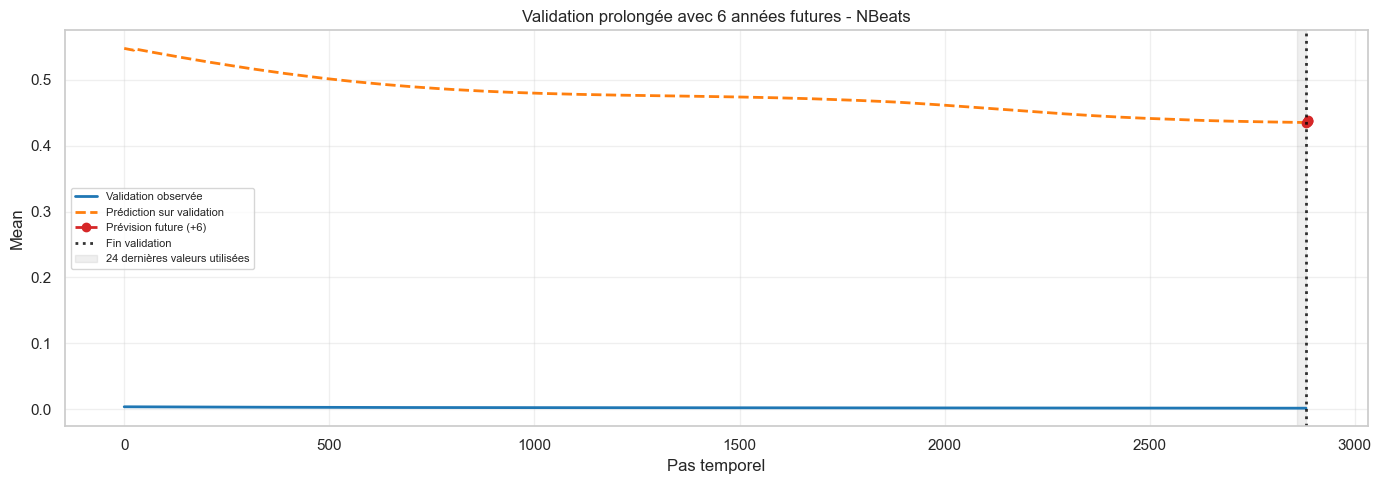

Modèle utilisé: NBeats
Les 6 années futures sont prédites à partir des 24 dernières valeurs de validation.


In [19]:
# === EXTENSION DE LA COURBE: 6 ANNÉES FUTURES PRÉDITES À LA FIN DE LA VALIDATION ===
# Cette cellule prend les 24 dernières valeurs observées de la validation,
# prédit les 6 années suivantes, puis ajoute cette extension à la courbe prédite.

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun résultat de modèle trouvé. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles.")
if 'freq_work' not in globals() or 'freq_target_col' not in globals() or 'target_scaler' not in globals():
    raise RuntimeError("Variables fréquence manquantes. Exécute d'abord la préparation des données fréquence.")
if 'val_frame' not in globals():
    raise RuntimeError("val_frame est manquant. Exécute d'abord le split train/validation.")

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name].to(device)
best_model.eval()

validation_original = pd.to_numeric(val_frame[freq_target_col], errors='coerce').interpolate(limit_direction='both').ffill().bfill().values.astype(float)
validation_scaled = np.asarray(
    val_y if 'val_y' in globals() else target_scaler.transform(val_frame[[freq_target_col]]),
    dtype=np.float32,
).reshape(-1)

if len(validation_scaled) < SEQ_INPUT_LEN:
    raise RuntimeError(f"Pas assez de points de validation pour utiliser les {SEQ_INPUT_LEN} dernières valeurs.")

# 1) Courbe observée sur toute la validation
validation_steps = np.arange(len(validation_original))

# 2) Prédiction sur la validation entière, pas à pas, pour avoir une courbe prédite jusqu'à la fin
#    puis on prolonge avec 6 pas futurs en auto-régression.
def predict_h1(model, window_scaled):
    x_tensor = torch.tensor(np.asarray(window_scaled, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return float(model(x_tensor).detach().cpu().numpy().reshape(-1)[0])

predicted_validation_scaled = []
history = validation_scaled[:SEQ_INPUT_LEN].tolist()
for step in range(len(validation_scaled) - SEQ_INPUT_LEN):
    pred_value = predict_h1(best_model, history[-SEQ_INPUT_LEN:])
    predicted_validation_scaled.append(pred_value)
    history.append(validation_scaled[SEQ_INPUT_LEN + step])

# Pour obtenir une prédiction alignée sur toute la validation, on complète les premiers points
# avec les observations réelles de la fenêtre d'entrée initiale.
predicted_validation_scaled = validation_scaled[:SEQ_INPUT_LEN].tolist() + predicted_validation_scaled
predicted_validation = target_scaler.inverse_transform(np.asarray(predicted_validation_scaled).reshape(-1, 1)).reshape(-1)

# 3) Extension future à partir des 24 dernières valeurs observées de validation
future_horizon = 6
future_history = validation_scaled[-SEQ_INPUT_LEN:].tolist()
future_pred_scaled = []
for _ in range(future_horizon):
    next_pred = predict_h1(best_model, future_history[-SEQ_INPUT_LEN:])
    future_pred_scaled.append(next_pred)
    future_history.append(next_pred)

future_pred = target_scaler.inverse_transform(np.asarray(future_pred_scaled).reshape(-1, 1)).reshape(-1)
future_steps = np.arange(len(validation_original), len(validation_original) + future_horizon)

# Aucune vraie valeur future n'existe ici: on affiche seulement la prolongation prédite
forecast_extension_df = pd.DataFrame({
    'step': future_steps,
    'predicted_future': future_pred,
    'model': best_model_name,
})

display(forecast_extension_df)

# Graphique: validation observée + courbe prédite prolongée
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(validation_steps, validation_original, color='tab:blue', linewidth=2, label='Validation observée')
ax.plot(validation_steps, predicted_validation, color='tab:orange', linewidth=2, linestyle='--', label='Prédiction sur validation')
ax.plot(future_steps, future_pred, color='tab:red', linewidth=2, linestyle='--', marker='o', label='Prévision future (+6)')
ax.axvline(len(validation_original) - 1, color='black', linestyle=':', linewidth=2, alpha=0.8, label='Fin validation')
ax.axvspan(len(validation_original) - SEQ_INPUT_LEN, len(validation_original) - 1, color='tab:gray', alpha=0.12, label='24 dernières valeurs utilisées')
ax.set_title(f"Validation prolongée avec 6 années futures - {best_model_name}")
ax.set_xlabel('Pas temporel')
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Modèle utilisé: {best_model_name}")
print(f"Les 6 années futures sont prédites à partir des 24 dernières valeurs de validation.")

,model,n_forecastable_points,MAE_direct,RMSE_direct,MAE_recursive,RMSE_recursive
0,NBeats,2858,0.000063,0.000064,0.004173,0.004282


,step,time,truth,pred_direct,pred_recursive,residual_direct,residual_recursive
0,24,10312.0,0.003713,0.003754,0.003754,-0.000042,-0.000042
1,25,10313.0,0.003710,0.003752,0.003758,-0.000042,-0.000047
2,26,10314.0,0.003708,0.003750,0.003762,-0.000042,-0.000054
3,27,10314.5,0.003707,0.003748,0.003766,-0.000041,-0.000060
4,28,10315.0,0.003705,0.003745,0.003770,-0.000040,-0.000064
5,29,10316.0,0.003703,0.003743,0.003774,-0.000040,-0.000071
6,30,10317.0,0.003701,0.003741,0.003781,-0.000041,-0.000080
7,31,10318.0,0.003698,0.003739,0.003787,-0.000041,-0.000089
8,32,10319.0,0.003696,0.003737,0.003795,-0.000041,-0.000099
9,33,10320.0,0.003693,0.003735,0.003803,-0.000042,-0.000110


,step,time,truth,pred_direct,pred_recursive,residual_direct,residual_recursive
2848,2872,12991.0,0.001646,0.001723,0.006757,-0.000077,-0.005111
2849,2873,12992.0,0.001646,0.001723,0.006757,-0.000077,-0.005111
2850,2874,12993.0,0.001646,0.001723,0.006757,-0.000077,-0.005111
2851,2875,12994.0,0.001646,0.001723,0.006757,-0.000077,-0.005111
2852,2876,12995.0,0.001645,0.001722,0.006757,-0.000077,-0.005111
2853,2877,12996.0,0.001645,0.001722,0.006757,-0.000077,-0.005112
2854,2878,12997.0,0.001645,0.001722,0.006757,-0.000077,-0.005112
2855,2879,12998.0,0.001645,0.001722,0.006757,-0.000077,-0.005112
2856,2880,12999.0,0.001645,0.001722,0.006757,-0.000077,-0.005112
2857,2881,13000.0,0.001645,0.001722,0.006757,-0.000077,-0.005112


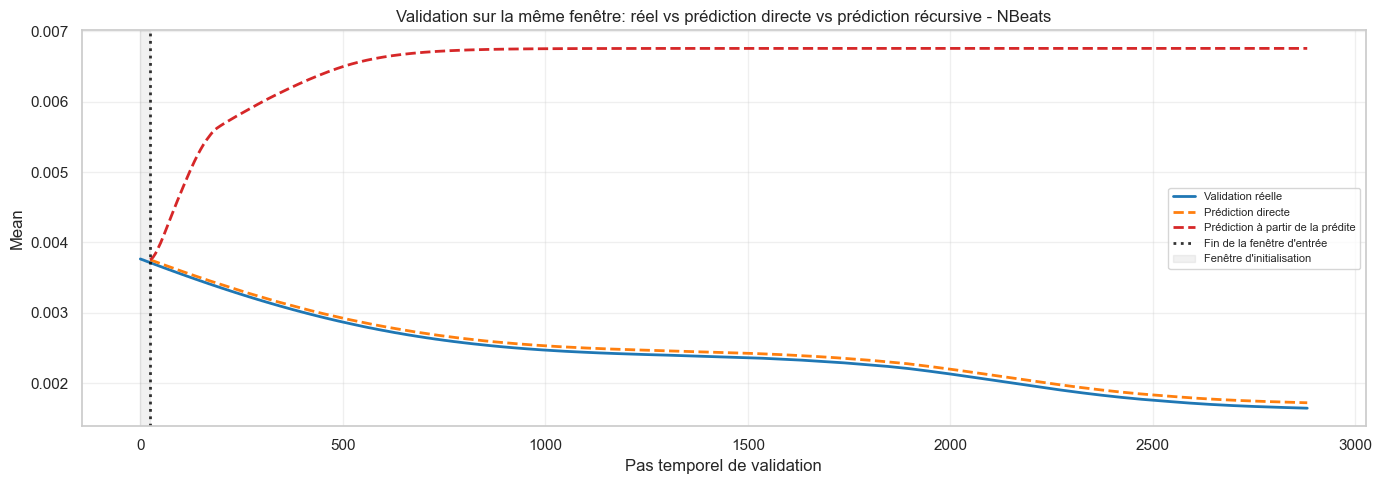

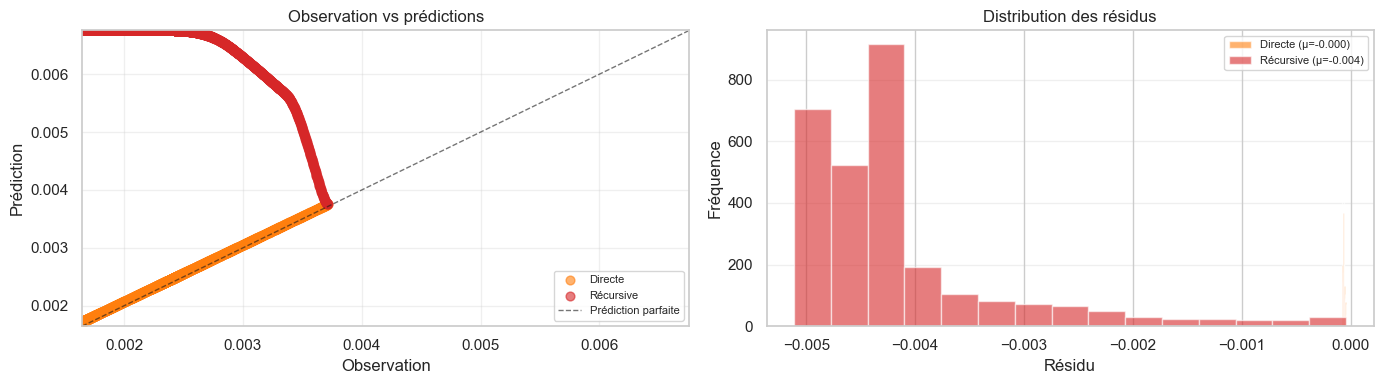

Modèle utilisé: NBeats
Nombre de points comparables sur la fenêtre: 2858
La courbe récursive reste dans la même fenêtre temporelle: elle n'est pas prolongée au-delà de la validation.


In [20]:
# === COMPARAISON SUR LA MEME FENETRE: REEL, PREVISION DIRECTE, PREVISION A PARTIR DE LA PREVISION ===
# Objectif: afficher les trois courbes sur la meme fenetre de validation,
# sans prolonger la courbe au-dela de la validation.

# - courbe reel: toute la validation,
# - courbe predite directe: chaque point futur est predit en utilisant les vraies valeurs precedentes,
# - courbe predite a partir de la predite: meme fenetre, mais les predictions sont re-injectees dans l'entree.

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun résultat de modèle trouvé. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'freq_work' not in globals() or 'freq_target_col' not in globals():
    raise RuntimeError("Variables fréquence manquantes. Exécute d'abord la préparation des données fréquence.")
if 'val_frame' not in globals():
    raise RuntimeError("val_frame est manquant. Exécute d'abord le split train/validation.")

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name].to(device)
best_model.eval()

freq_scaler = globals().get('freq_target_scaler', None)
if freq_scaler is None:
    if 'train_frame' not in globals():
        raise RuntimeError("freq_target_scaler est manquant et train_frame n'est pas disponible pour le reconstruire.")
    freq_scaler = StandardScaler()
    freq_scaler.fit(train_frame[[freq_target_col]])

validation_original = pd.to_numeric(val_frame[freq_target_col], errors='coerce').interpolate(limit_direction='both').ffill().bfill().values.astype(float)
validation_scaled = np.asarray(
    val_y if 'val_y' in globals() else freq_scaler.transform(val_frame[[freq_target_col]]),
    dtype=np.float32,
).reshape(-1)

if len(validation_scaled) < SEQ_INPUT_LEN + 2:
    raise RuntimeError(f"Pas assez de points de validation pour comparer sur la même fenêtre (SEQ_INPUT_LEN={SEQ_INPUT_LEN}).")

def predict_first_horizon(model, window_scaled):
    x_tensor = torch.tensor(np.asarray(window_scaled, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return float(model(x_tensor).detach().cpu().numpy().reshape(-1)[0])

forecast_steps = np.arange(SEQ_INPUT_LEN, len(validation_scaled))
if len(forecast_steps) == 0:
    raise RuntimeError("La validation est trop courte pour produire une comparaison utile.")

# 1) Prédiction directe: à chaque pas, on utilise les vraies valeurs précédentes
pred_direct_scaled = []
for step in forecast_steps:
    window = validation_scaled[step - SEQ_INPUT_LEN:step]
    pred_direct_scaled.append(predict_first_horizon(best_model, window))

# 2) Prédiction à partir de la prédiction: la sortie précédente est réinjectée dans l'entrée
pred_recursive_scaled = []
history = validation_scaled[:SEQ_INPUT_LEN].tolist()
for _ in forecast_steps:
    window = history[-SEQ_INPUT_LEN:]
    next_pred = predict_first_horizon(best_model, window)
    pred_recursive_scaled.append(next_pred)
    history.append(next_pred)

# Retour à l'échelle originale
truth_window = validation_original[forecast_steps]
pred_direct = freq_scaler.inverse_transform(np.asarray(pred_direct_scaled).reshape(-1, 1)).reshape(-1)
pred_recursive = freq_scaler.inverse_transform(np.asarray(pred_recursive_scaled).reshape(-1, 1)).reshape(-1)

# Axe de temps si disponible, sinon index relatif
if 'freq_time_col' in globals() and freq_time_col in val_frame.columns:
    time_axis = val_frame[freq_time_col].iloc[forecast_steps].reset_index(drop=True)
else:
    time_axis = pd.Series(forecast_steps)

comparison_same_window_df = pd.DataFrame({
    'step': forecast_steps,
    'time': time_axis,
    'truth': truth_window,
    'pred_direct': pred_direct,
    'pred_recursive': pred_recursive,
})
comparison_same_window_df['residual_direct'] = comparison_same_window_df['truth'] - comparison_same_window_df['pred_direct']
comparison_same_window_df['residual_recursive'] = comparison_same_window_df['truth'] - comparison_same_window_df['pred_recursive']

summary_same_window = pd.DataFrame([
    {
        'model': best_model_name,
        'n_forecastable_points': len(comparison_same_window_df),
        'MAE_direct': mean_absolute_error(comparison_same_window_df['truth'], comparison_same_window_df['pred_direct']),
        'RMSE_direct': float(np.sqrt(mean_squared_error(comparison_same_window_df['truth'], comparison_same_window_df['pred_direct']))),
        'MAE_recursive': mean_absolute_error(comparison_same_window_df['truth'], comparison_same_window_df['pred_recursive']),
        'RMSE_recursive': float(np.sqrt(mean_squared_error(comparison_same_window_df['truth'], comparison_same_window_df['pred_recursive']))),
    }
])

display(summary_same_window)
display(comparison_same_window_df.head(10))
display(comparison_same_window_df.tail(10))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(np.arange(len(validation_original)), validation_original, color='tab:blue', linewidth=2, label='Validation réelle')
ax.plot(comparison_same_window_df['step'], comparison_same_window_df['pred_direct'], color='tab:orange', linewidth=2, linestyle='--', label='Prédiction directe')
ax.plot(comparison_same_window_df['step'], comparison_same_window_df['pred_recursive'], color='tab:red', linewidth=2, linestyle='--', label='Prédiction à partir de la prédite')
ax.axvline(SEQ_INPUT_LEN - 0.5, color='black', linestyle=':', linewidth=2, alpha=0.8, label='Fin de la fenêtre d\'entrée')
ax.axvspan(0, SEQ_INPUT_LEN - 1, color='tab:gray', alpha=0.10, label='Fenêtre d\'initialisation')
ax.set_title(f"Validation sur la même fenêtre: réel vs prédiction directe vs prédiction récursive - {best_model_name}")
ax.set_xlabel('Pas temporel de validation')
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.scatter(comparison_same_window_df['truth'], comparison_same_window_df['pred_direct'], alpha=0.6, s=40, color='tab:orange', label='Directe')
ax.scatter(comparison_same_window_df['truth'], comparison_same_window_df['pred_recursive'], alpha=0.6, s=40, color='tab:red', label='Récursive')
lims = [
    np.nanmin([comparison_same_window_df['truth'].min(), comparison_same_window_df['pred_direct'].min(), comparison_same_window_df['pred_recursive'].min()]),
    np.nanmax([comparison_same_window_df['truth'].max(), comparison_same_window_df['pred_direct'].max(), comparison_same_window_df['pred_recursive'].max()]),
]
ax.plot(lims, lims, 'k--', alpha=0.6, linewidth=1, label='Prédiction parfaite')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title('Observation vs prédictions')
ax.set_xlabel('Observation')
ax.set_ylabel('Prédiction')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
residual_direct = comparison_same_window_df['residual_direct']
residual_recursive = comparison_same_window_df['residual_recursive']
ax.hist(residual_direct, bins=15, alpha=0.6, color='tab:orange', label=f'Directe (μ={residual_direct.mean():.3f})')
ax.hist(residual_recursive, bins=15, alpha=0.6, color='tab:red', label=f'Récursive (μ={residual_recursive.mean():.3f})')
ax.set_title('Distribution des résidus')
ax.set_xlabel('Résidu')
ax.set_ylabel('Fréquence')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Modèle utilisé: {best_model_name}")
print(f"Nombre de points comparables sur la fenêtre: {len(comparison_same_window_df)}")
print("La courbe récursive reste dans la même fenêtre temporelle: elle n'est pas prolongée au-delà de la validation.")

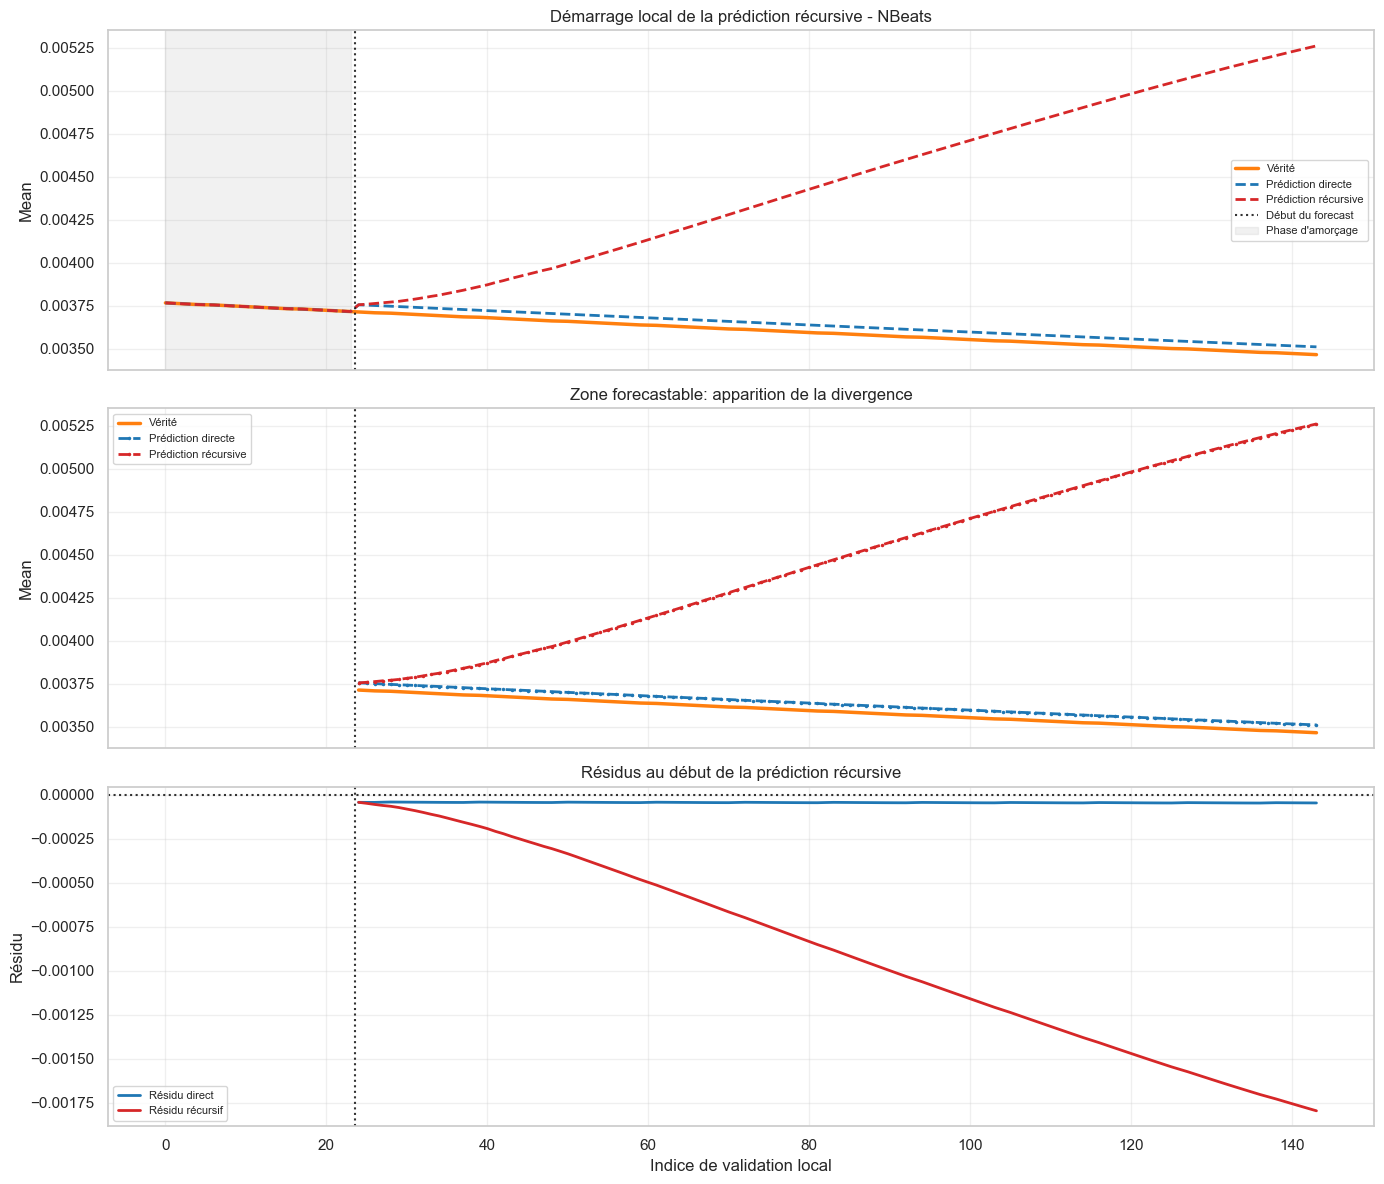

,model,zoom_start,zoom_end,axis_used,n_points_zoom,warmup_len,MAE_direct_zoom,RMSE_direct_zoom,MAE_recursive_zoom,RMSE_recursive_zoom
0,NBeats,24,143,local_step,120,24,0.000043,0.000043,0.000888,0.001041


,step,time,truth,pred_direct,pred_recursive,residual_direct,residual_recursive
0,24,10312.0,0.003713,0.003754,0.003754,-0.000042,-0.000042
1,25,10313.0,0.003710,0.003752,0.003758,-0.000042,-0.000047
2,26,10314.0,0.003708,0.003750,0.003762,-0.000042,-0.000054
3,27,10314.5,0.003707,0.003748,0.003766,-0.000041,-0.000060
4,28,10315.0,0.003705,0.003745,0.003770,-0.000040,-0.000064
5,29,10316.0,0.003703,0.003743,0.003774,-0.000040,-0.000071
6,30,10317.0,0.003701,0.003741,0.003781,-0.000041,-0.000080
7,31,10318.0,0.003698,0.003739,0.003787,-0.000041,-0.000089
8,32,10319.0,0.003696,0.003737,0.003795,-0.000041,-0.000099
9,33,10320.0,0.003693,0.003735,0.003803,-0.000042,-0.000110


,step,time,truth,pred_direct,pred_recursive,residual_direct,residual_recursive
110,134,10412.0,0.003482,0.003527,0.005157,-0.000045,-0.001675
111,135,10413.0,0.003480,0.003525,0.005169,-0.000046,-0.001689
112,136,10414.0,0.003478,0.003523,0.005181,-0.000046,-0.001703
113,137,10414.5,0.003476,0.003521,0.005192,-0.000045,-0.001716
114,138,10415.0,0.003475,0.003519,0.005204,-0.000044,-0.001728
115,139,10416.0,0.003473,0.003517,0.005215,-0.000044,-0.001742
116,140,10417.0,0.003471,0.003515,0.005227,-0.000044,-0.001756
117,141,10418.0,0.003469,0.003514,0.005238,-0.000045,-0.001769
118,142,10419.0,0.003467,0.003512,0.005249,-0.000045,-0.001782
119,143,10420.0,0.003464,0.003510,0.005260,-0.000045,-0.001796


Zoom local effectué sur 120 points avec une phase d'amorçage de 24 vraies valeurs.


In [21]:
# === ZOOM LOCAL AU DÉMARRAGE DE LA PRÉDICTION RÉCursive ===
# Objectif: voir le moment exact où la courbe récursive cesse d'utiliser
# uniquement les vraies valeurs et commence à réinjecter ses propres prédictions.
#
# Lecture du graphe:
# - orange: vérité complète sur la zone locale,
# - bleu: prédiction directe,
# - rouge: prédiction récursive avec une phase d'amorçage sur les vraies valeurs,
#   puis bascule vers ses propres sorties.

if 'comparison_same_window_df' not in globals():
    raise RuntimeError("comparison_same_window_df est manquant. Exécute d'abord la cellule de comparaison sur la même fenêtre.")
if 'val_frame' not in globals() or 'freq_target_col' not in globals():
    raise RuntimeError("Variables de validation manquantes. Exécute d'abord la préparation de validation.")

zoom_df = comparison_same_window_df.sort_values('step').copy()

# On garde une fenêtre locale au début de la zone forecastable pour voir la rupture.
zoom_forecast_len = min(120, len(zoom_df))
zoom_df_idx = zoom_df.head(zoom_forecast_len).copy()
if zoom_df_idx.empty:
    raise RuntimeError("Aucun point dans la fenêtre de zoom locale avec les données actuelles.")

# Phase d'amorçage: on ajoute les vraies valeurs avant le premier pas forecastable.
warmup_truth = pd.to_numeric(val_frame[freq_target_col], errors='coerce').interpolate(limit_direction='both').ffill().bfill().values.astype(float)
warmup_truth = warmup_truth[:SEQ_INPUT_LEN]
if len(warmup_truth) < SEQ_INPUT_LEN:
    raise RuntimeError(f"Pas assez de valeurs vraies pour amorcer la récursion ({len(warmup_truth)} < {SEQ_INPUT_LEN}).")

local_truth = np.concatenate([warmup_truth, zoom_df_idx['truth'].to_numpy()])
local_direct = np.concatenate([warmup_truth, zoom_df_idx['pred_direct'].to_numpy()])
local_recursive = np.concatenate([warmup_truth, zoom_df_idx['pred_recursive'].to_numpy()])
local_steps = np.arange(len(local_truth))
split_idx = SEQ_INPUT_LEN

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1) Vue d'ensemble locale: vérité + direct + récursif
ax = axes[0]
ax.plot(local_steps, local_truth, color='tab:orange', linewidth=2.5, label='Vérité')
ax.plot(local_steps, local_direct, color='tab:blue', linewidth=2, linestyle='--', label='Prédiction directe')
ax.plot(local_steps, local_recursive, color='tab:red', linewidth=2, linestyle='--', label='Prédiction récursive')
ax.axvline(split_idx - 0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.8, label='Début du forecast')
ax.axvspan(0, split_idx - 1, color='tab:gray', alpha=0.10, label="Phase d'amorçage")
ax.set_title(f"Démarrage local de la prédiction récursive - {best_model_name}")
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# 2) Zoom uniquement sur la zone forecastable: on voit le moment où le rouge se désolidarise.
ax = axes[1]
forecast_steps = np.arange(split_idx, split_idx + len(zoom_df_idx))
ax.plot(forecast_steps, zoom_df_idx['truth'], color='tab:orange', linewidth=2.5, label='Vérité')
ax.plot(forecast_steps, zoom_df_idx['pred_direct'], color='tab:blue', linewidth=2, linestyle='--', marker='.', markersize=3, label='Prédiction directe')
ax.plot(forecast_steps, zoom_df_idx['pred_recursive'], color='tab:red', linewidth=2, linestyle='--', marker='.', markersize=3, label='Prédiction récursive')
ax.axvline(split_idx - 0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.8)
ax.set_ylabel(freq_target_col)
ax.set_title('Zone forecastable: apparition de la divergence')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# 3) Résidus sur la zone forecastable
ax = axes[2]
ax.plot(forecast_steps, zoom_df_idx['residual_direct'], color='tab:blue', linewidth=2, label='Résidu direct')
ax.plot(forecast_steps, zoom_df_idx['residual_recursive'], color='tab:red', linewidth=2, label='Résidu récursif')
ax.axhline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.8)
ax.axvline(split_idx - 0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Indice de validation local')
ax.set_ylabel('Résidu')
ax.set_title('Résidus au début de la prédiction récursive')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

zoom_summary = pd.DataFrame([
    {
        'model': best_model_name,
        'zoom_start': int(zoom_df_idx['step'].min()),
        'zoom_end': int(zoom_df_idx['step'].max()),
        'axis_used': 'local_step',
        'n_points_zoom': len(zoom_df_idx),
        'warmup_len': SEQ_INPUT_LEN,
        'MAE_direct_zoom': mean_absolute_error(zoom_df_idx['truth'], zoom_df_idx['pred_direct']),
        'RMSE_direct_zoom': float(np.sqrt(mean_squared_error(zoom_df_idx['truth'], zoom_df_idx['pred_direct']))),
        'MAE_recursive_zoom': mean_absolute_error(zoom_df_idx['truth'], zoom_df_idx['pred_recursive']),
        'RMSE_recursive_zoom': float(np.sqrt(mean_squared_error(zoom_df_idx['truth'], zoom_df_idx['pred_recursive']))),
    }
])

display(zoom_summary)
display(zoom_df_idx.head(10))
display(zoom_df_idx.tail(10))

print(f"Zoom local effectué sur {len(zoom_df_idx)} points avec une phase d'amorçage de {SEQ_INPUT_LEN} vraies valeurs.")

,model,final_train_loss,direct_mae,direct_rmse,recursive_mae,recursive_rmse,recursive_drift
0,TransformerPatch,0.011514,129.998032,136.957552,452.940247,480.680962,704.902832
1,NBeats,0.007336,106.289314,109.524166,911.629639,987.159087,1449.731445
2,LSTMPatch,0.011847,181.864182,185.442714,1530.405884,1695.450456,2740.504883
3,TemporalFusionTransformer,0.008064,230.918640,234.002971,1939.688721,2194.059138,3589.077637


,step,truth,direct_pred,recursive_pred,direct_residual,recursive_residual
0,1,8009.340332,7933.295898,7933.295898,76.044434,76.044434
1,2,8032.908691,7929.540527,7925.825195,103.368164,107.083496
2,3,8033.395508,7932.215332,7923.917480,101.180176,109.478027
3,4,7992.726074,7933.118164,7922.495605,59.607910,70.230469
4,5,8009.850586,7933.676758,7919.802246,76.173828,90.048340
5,6,7959.397461,7936.394531,7918.833008,23.002930,40.564453
6,7,8009.477539,7932.920410,7914.932617,76.557129,94.544922
7,8,7988.150391,7932.989746,7914.841797,55.160645,73.308594
8,9,8004.340332,7936.317871,7914.875977,68.022461,89.464355
9,10,7967.865723,7934.768066,7912.143555,33.097656,55.722168


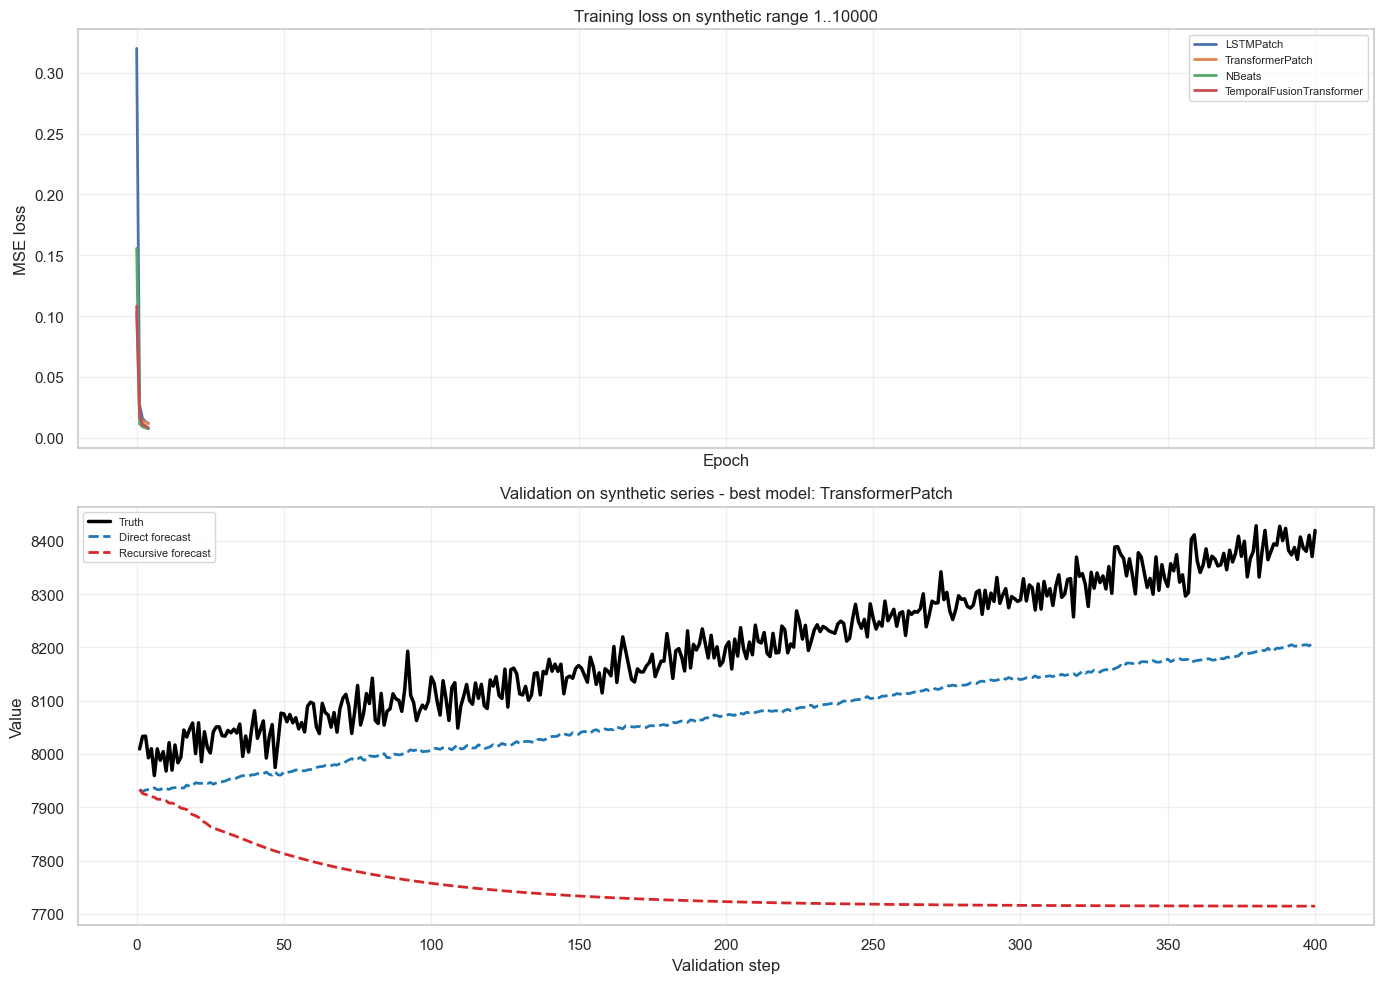

Best model by recursive MAE: TransformerPatch
On this trivial monotonic series, the recursive forecast should stay close to the line if the model learned the next-step progression.


In [22]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

if 'MODEL_CONFIGS' not in globals():
    raise RuntimeError('MODEL_CONFIGS is missing. Execute the model definition cells first.')
if 'SEQ_INPUT_LEN' not in globals() or 'SEQ_HORIZON' not in globals():
    raise RuntimeError('SEQ_INPUT_LEN or SEQ_HORIZON is missing. Execute the sequence setup cells first.')

# Synthetic monotonic series: 1..10000 + bruit blanc gaussien
rng = np.random.default_rng(42)
noise_std = 25.0
simple_values = np.arange(1, 10001, dtype=np.float32) + rng.normal(0.0, noise_std, 10000).astype(np.float32)
simple_df = pd.DataFrame({'step': np.arange(1, len(simple_values) + 1), 'value': simple_values})

# Time split: train on the first part, validate on the last part.
train_fraction = 0.80
train_end = int(len(simple_values) * train_fraction)
val_horizon = min(400, len(simple_values) - train_end)
if val_horizon <= 0:
    raise RuntimeError('Validation horizon is too small for the synthetic experiment.')

scaler = StandardScaler()
train_scaled = scaler.fit_transform(simple_values[:train_end].reshape(-1, 1)).reshape(-1).astype(np.float32)
full_scaled = scaler.transform(simple_values.reshape(-1, 1)).reshape(-1).astype(np.float32)

class SequenceWindowDataset(Dataset):
    def __init__(self, series, input_len, pred_len):
        self.series = np.asarray(series, dtype=np.float32)
        self.input_len = int(input_len)
        self.pred_len = int(pred_len)
        self.length = max(0, len(self.series) - self.input_len - self.pred_len + 1)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        idx = int(idx)
        x = self.series[idx:idx + self.input_len]
        y = self.series[idx + self.input_len:idx + self.input_len + self.pred_len]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


def unpack_model_config(config):
    if isinstance(config, dict):
        model_name = config.get('name') or config.get('model_name') or config.get('model')
        if model_name is None:
            raise RuntimeError(f'Unsupported model config dict: {config!r}')
        model_kwargs = config.get('kwargs') or config.get('params') or config.get('init_kwargs')
        if model_kwargs is None:
            model_kwargs = {k: v for k, v in config.items() if k not in {'name', 'model_name', 'model', 'kwargs', 'params', 'init_kwargs'}}
        return model_name, dict(model_kwargs)
    if isinstance(config, (tuple, list)) and len(config) == 2:
        return config[0], dict(config[1])
    raise RuntimeError(f'Unsupported model config format: {type(config).__name__}')


def build_model(model_name, model_kwargs):
    model_cls = globals().get(model_name)
    if model_cls is None:
        raise RuntimeError(f'Model class {model_name} is not available in the notebook.')
    model_kwargs = dict(model_kwargs)
    model_kwargs.pop('seq_len', None)
    model_kwargs.pop('pred_len', None)
    return model_cls(seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, **model_kwargs)


def train_model(model, loader, epochs=5, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    model.to(device)
    for _ in range(epochs):
        model.train()
        total_loss = 0.0
        total_count = 0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            batch_size = xb.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size
        history.append(total_loss / max(1, total_count))
    return history


def inverse_1d(values):
    values = np.asarray(values, dtype=np.float32).reshape(-1, 1)
    return scaler.inverse_transform(values).reshape(-1)


def direct_one_step_forecast(model, start_index, eval_steps):
    preds = []
    truths = []
    model.eval()
    with torch.no_grad():
        for step in range(eval_steps):
            end_index = start_index + step
            x_window = full_scaled[end_index - SEQ_INPUT_LEN:end_index]
            y_true = full_scaled[end_index]
            x_tensor = torch.tensor(x_window, dtype=torch.float32, device=device).unsqueeze(0)
            y_pred = model(x_tensor).detach().cpu().numpy().reshape(-1)[0]
            preds.append(y_pred)
            truths.append(y_true)
    return np.asarray(preds, dtype=np.float32), np.asarray(truths, dtype=np.float32)


def recursive_one_step_forecast(model, start_window, eval_steps):
    window = np.asarray(start_window, dtype=np.float32).copy()
    preds = []
    model.eval()
    with torch.no_grad():
        for _ in range(eval_steps):
            x_tensor = torch.tensor(window, dtype=torch.float32, device=device).unsqueeze(0)
            y_pred = model(x_tensor).detach().cpu().numpy().reshape(-1)[0]
            preds.append(y_pred)
            window = np.concatenate([window[1:], np.array([y_pred], dtype=np.float32)])
    return np.asarray(preds, dtype=np.float32)

train_dataset = SequenceWindowDataset(train_scaled, SEQ_INPUT_LEN, SEQ_HORIZON)
train_loader = DataLoader(train_dataset, batch_size=min(256, max(16, len(train_dataset))), shuffle=True, drop_last=False)

model_entries = []
for raw_config in MODEL_CONFIGS:
    model_name, model_kwargs = unpack_model_config(raw_config)
    if model_name not in globals():
        continue
    model_entries.append((model_name, model_kwargs))

if not model_entries:
    model_entries = [
        ('LSTMPatch', {'patch_size': 4, 'hidden_dim': 128, 'num_layers': 1, 'dropout': 0.1}),
        ('TransformerPatch', {'patch_size': 4, 'd_model': 128, 'nhead': 4, 'num_layers': 2, 'dropout': 0.1, 'dim_ff': 128}),
        ('NBeats', {'hidden_dim': 128, 'num_blocks': 2, 'num_layers': 3, 'dropout': 0.1}),
        ('TemporalFusionTransformer', {'d_model': 128, 'nhead': 4, 'num_layers': 2, 'dropout': 0.1}),
    ]

simple_models = {}
simple_histories = {}
simple_results = []

# Keep the demo fast enough while still showing the behavior on a trivial series.
epochs = 5
lr = 1e-3
for model_name, model_kwargs in model_entries:
    model = build_model(model_name, copy.deepcopy(model_kwargs))
    history = train_model(model, train_loader, epochs=epochs, lr=lr)
    simple_models[model_name] = model
    simple_histories[model_name] = history

    direct_pred_scaled, truth_scaled = direct_one_step_forecast(model, train_end, val_horizon)
    recursive_pred_scaled = recursive_one_step_forecast(model, full_scaled[train_end - SEQ_INPUT_LEN:train_end], val_horizon)

    direct_pred = inverse_1d(direct_pred_scaled)
    truth = inverse_1d(truth_scaled)
    recursive_pred = inverse_1d(recursive_pred_scaled)

    simple_results.append({
        'model': model_name,
        'final_train_loss': history[-1],
        'direct_mae': mean_absolute_error(truth, direct_pred),
        'direct_rmse': float(np.sqrt(mean_squared_error(truth, direct_pred))),
        'recursive_mae': mean_absolute_error(truth, recursive_pred),
        'recursive_rmse': float(np.sqrt(mean_squared_error(truth, recursive_pred))),
        'recursive_drift': float(np.abs(recursive_pred[-1] - truth[-1])),
    })

simple_results_df = pd.DataFrame(simple_results).sort_values(['recursive_mae', 'direct_mae']).reset_index(drop=True)
display(simple_results_df)

best_simple_model_name = simple_results_df.iloc[0]['model']
best_simple_model = simple_models[best_simple_model_name]

best_direct_scaled, best_truth_scaled = direct_one_step_forecast(best_simple_model, train_end, val_horizon)
best_recursive_scaled = recursive_one_step_forecast(best_simple_model, full_scaled[train_end - SEQ_INPUT_LEN:train_end], val_horizon)

best_simple_df = pd.DataFrame({
    'step': np.arange(1, val_horizon + 1),
    'truth': inverse_1d(best_truth_scaled),
    'direct_pred': inverse_1d(best_direct_scaled),
    'recursive_pred': inverse_1d(best_recursive_scaled),
})
best_simple_df['direct_residual'] = best_simple_df['truth'] - best_simple_df['direct_pred']
best_simple_df['recursive_residual'] = best_simple_df['truth'] - best_simple_df['recursive_pred']
display(best_simple_df.head(12))

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
for model_name, history in simple_histories.items():
    ax.plot(history, linewidth=2, label=model_name)
ax.set_title('Training loss on synthetic range 1..10000')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(best_simple_df['step'], best_simple_df['truth'], color='black', linewidth=2.5, label='Truth')
ax.plot(best_simple_df['step'], best_simple_df['direct_pred'], color='tab:blue', linestyle='--', linewidth=2, label='Direct forecast')
ax.plot(best_simple_df['step'], best_simple_df['recursive_pred'], color='tab:red', linestyle='--', linewidth=2, label='Recursive forecast')
ax.set_title(f'Validation on synthetic series - best model: {best_simple_model_name}')
ax.set_xlabel('Validation step')
ax.set_ylabel('Value')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Best model by recursive MAE: {best_simple_model_name}')
print('On this trivial monotonic series, the recursive forecast should stay close to the line if the model learned the next-step progression.')

## Export de toutes les images du notebook
Cette cellule extrait les images deja presentes dans les sorties du notebook et les enregistre dans un dossier local. Elle permet de recuperer toutes les figures affichees sans modifier les cellules de calcul.

In [ ]:
from pathlib import Path
import base64
import json
import re
import unicodedata
from collections import defaultdict

notebook_path = Path('exploration_variables_modeles_feu.BACKUP.ipynb')
output_dir = Path('figures_notebook_outputs')
output_dir.mkdir(exist_ok=True)

for existing_file in output_dir.iterdir():
    if existing_file.suffix.lower() in {'.png', '.jpg', '.jpeg', '.svg'}:
        existing_file.unlink()


def slugify(text, fallback):
    normalized = unicodedata.normalize('NFKD', str(text)).encode('ascii', 'ignore').decode('ascii')
    normalized = normalized.lower()
    normalized = re.sub(r'[^a-z0-9]+', '-', normalized)
    normalized = re.sub(r'-+', '-', normalized).strip('-')
    return normalized[:60] or fallback


def infer_base_name(cell, cell_index):
    source_text = ''.join(cell.get('source', []))

    title_patterns = [
        r"(?:ax|axes\[[^\]]+\]|plt|fig)\.(?:set_title|suptitle|title)\(\s*[rR]?[\"']([^\"']+)[\"']",
        r"set_title\(\s*[rR]?[\"']([^\"']+)[\"']",
        r"suptitle\(\s*[rR]?[\"']([^\"']+)[\"']",
        r"title\(\s*[rR]?[\"']([^\"']+)[\"']",
    ]
    for pattern in title_patterns:
        match = re.search(pattern, source_text)
        if match:
            candidate = match.group(1).strip()
            if candidate:
                return slugify(candidate, f'cell-{cell_index:03d}')

    generic_comment_prefixes = (
        'cette cellule',
        'objectif',
        'but',
        'note',
        'remarque',
        'suppose',
    )

    comment_lines = []
    for line in cell.get('source', []):
        stripped = line.strip()
        if not stripped.startswith('#'):
            continue
        cleaned = stripped.lstrip('#').strip()
        if not cleaned or cleaned.startswith('==='):
            continue
        if cleaned.lower().startswith(generic_comment_prefixes):
            continue
        comment_lines.append(cleaned)
    if comment_lines:
        return slugify(comment_lines[0], f'cell-{cell_index:03d}')

    for line in cell.get('source', []):
        stripped = line.strip()
        if not stripped:
            continue
        if stripped.startswith('import ') or stripped.startswith('from '):
            continue
        if stripped.startswith('if ') or stripped.startswith('for ') or stripped.startswith('while '):
            continue
        return slugify(stripped, f'cell-{cell_index:03d}')

    return f'cell-{cell_index:03d}'


with notebook_path.open('r', encoding='utf-8') as f:
    notebook = json.load(f)

saved_files = []
name_counters = defaultdict(int)

for cell_index, cell in enumerate(notebook.get('cells', []), start=1):
    if cell.get('cell_type') != 'code':
        continue

    base_name = infer_base_name(cell, cell_index)

    for output in cell.get('outputs', []):
        data = output.get('data', {})
        for mime, ext in [('image/png', 'png'), ('image/jpeg', 'jpg'), ('image/svg+xml', 'svg')]:
            if mime not in data:
                continue

            name_counters[(base_name, ext)] += 1
            suffix = name_counters[(base_name, ext)]
            filename = f'{base_name}-{suffix:02d}.{ext}'
            file_path = output_dir / filename
            payload = data[mime]

            if ext in {'png', 'jpg'}:
                with file_path.open('wb') as f:
                    f.write(base64.b64decode(payload))
            else:
                with file_path.open('w', encoding='utf-8') as f:
                    f.write(payload)

            saved_files.append(str(file_path))

print(f'{len(saved_files)} image(s) enregistree(s) dans {output_dir.resolve()}')
for path in saved_files[:20]:
    print(path)
if len(saved_files) > 20:
    print(f'... + {len(saved_files) - 20} autre(s) fichier(s)')

25 image(s) enregistree(s) dans C:\Users\lenovo\Downloads\Foret_Boreal\figures_notebook_outputs
figures_notebook_outputs\distribution-rmse-par-periode-intensite-01.png
figures_notebook_outputs\distribution-rmse-par-periode-intensite-02.png
figures_notebook_outputs\distribution-rmse-par-periode-intensite-03.png
figures_notebook_outputs\distribution-rmse-par-periode-intensite-04.png
figures_notebook_outputs\distribution-rmse-par-periode-intensite-05.png
figures_notebook_outputs\distribution-rmse-par-periode-intensite-06.png
figures_notebook_outputs\distribution-rmse-par-periode-intensite-07.png
figures_notebook_outputs\distribution-rmse-par-periode-intensite-08.png
figures_notebook_outputs\distribution-rmse-par-periode-intensite-09.png
figures_notebook_outputs\erreurs-de-validation-premier-horizon-01.png
figures_notebook_outputs\erreurs-de-validation-premier-horizon-02.png
figures_notebook_outputs\erreurs-de-validation-premier-horizon-03.png
figures_notebook_outputs\erreurs-de-validation

In [ ]:
from pathlib import Path
import re


def _sanitize_model_name(model_name):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(model_name)).strip('_') or 'model'


def _save_model_weights(models_dict, output_dir, proxy_name):
    if not isinstance(models_dict, dict) or len(models_dict) == 0:
        print(f"Aucun modèle à sauvegarder pour le proxy {proxy_name}.")
        return []

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = []
    for model_name, model in models_dict.items():
        if not hasattr(model, 'state_dict'):
            print(f"Modèle ignoré (pas de state_dict): {model_name}")
            continue

        file_path = output_dir / f"proxy_{_sanitize_model_name(proxy_name)}_{_sanitize_model_name(model_name)}.pth"
        torch.save(
            {
                'model_name': model_name,
                'model_type': type(model).__name__,
                'proxy_name': proxy_name,
                'state_dict': {key: value.detach().cpu() for key, value in model.state_dict().items()},
            },
            file_path,
        )
        saved_paths.append(file_path)

    if saved_paths:
        print(f"{len(saved_paths)} fichier(s) de poids sauvegardé(s) pour le proxy {proxy_name} dans {output_dir}")
        for path in saved_paths:
            print(f"- {path}")
    return saved_paths


weights_root = Path('model_weights')
saved_weight_files = []

if 'trained_models' in globals():
    saved_weight_files += _save_model_weights(trained_models, weights_root / 'frequency', 'frequency')

if 'intensity_trained_models' in globals():
    saved_weight_files += _save_model_weights(intensity_trained_models, weights_root / 'intensity', 'intensity')

if not saved_weight_files:
    print("Aucun dictionnaire de modèles entraînés n'a été trouvé dans l'environnement courant.")